# AgroFlix: recomendador de cultivos con capa económico-financiera

Este cuaderno es parte del Trabajo Fin de Máster *AgroFlix: sistema de recomendación de cultivos con rentabilidad ajustada al riesgo*  y permite reproducir, de principio a fin, el experimento descrito en la memoria.

La idea del trabajo es sencilla. Cada campaña, el agricultor tiene que decidir qué sembrar en cada una de sus parcelas, y esa decisión se parece mucho a la que resuelve un sistema de recomendación como el de Netflix. Por eso, en este trabajo la **parcela** hace el papel de usuario, el **cultivo** hace el papel de ítem, y la **declaración de siembra** de la PAC (lo que el agricultor declara haber sembrado cada año) hace el papel de interacción. Con esos datos se entrena un recomendador que propone, para cada parcela, una lista ordenada de cultivos. Después, una segunda capa añade a cada cultivo recomendado su margen esperado por hectárea y una medida de su riesgo, de modo que el resultado se pueda leer también en términos financieros.

## Estructura del cuaderno

La tabla siguiente indica qué contiene cada sección y en qué parte de la memoria se explica.

| Sección del cuaderno | Contenido | Memoria |
|---|---|---|
| 1. Capa de datos | Muestra de parcelas, *score* de confianza y características de cada parcela | Capítulo 3 (secciones 3.4 y 3.5) |
| 2. Análisis exploratorio | Comprobaciones de que los datos construidos son coherentes | Sección 3.5.4 |
| 3. Núcleo recomendador | Preparación de los datos, métricas y las ocho variantes que se comparan | Secciones 3.7 y 4.1 |
| 4. Escenario A | Evaluación temporal: se entrena con 2023-2024 y se evalúa con 2025 | Secciones 3.7.1 y 4.2.1 |
| 5. Escenario B | Evaluación con parcelas nuevas (*cold start*), repetida con diez semillas | Secciones 3.7.2 y 4.2.2 |
| 6. Resultados | Tablas principales, métricas completas y figuras | Sección 4.2 y anexo A |
| 7. Capa económico-financiera | Ficha económica por cultivo, riesgo, reordenación y financiación | Secciones 4.3 y 4.4 |

## Cómo ejecutarlo

- **Entorno.** Hace falta Python 3.13 con las librerías que se importan en la primera celda: `pandas`, `numpy`, `scipy`, `geopandas`, `pyproj`, `rasterio`, `xarray`, `lightfm`, `implicit`, `scikit-learn`, `xgboost`, `matplotlib`, `requests` y `tqdm`.
- **Datos.** Todas las fuentes son abiertas (DACC, IGN, ISRIC SoilGrids, LUCAS Soil, Meteocat, XCAC e INE). La primera vez que se ejecuta el cuaderno, los datos se descargan y se guardan en la carpeta `data/raw/`. En las ejecuciones siguientes se reutilizan esos ficheros, así que la primera ejecución es bastante más lenta que las demás. En todos los casos es necesaria una conexión a internet.
- **Tiempo.** Con los datos ya descargados, la ejecución completa tarda unos 25 minutos en un portátil de 8 núcleos y 16 GB de RAM. La celda más lenta es la evaluación del escenario B, porque entrena las ocho variantes diez veces.
- **Reproducibilidad.** Todas las operaciones con un componente aleatorio usan una semilla fija, de modo que dos ejecuciones dan el mismo resultado. Por el mismo motivo, el modelo que genera las recomendaciones de la capa económica se entrena con un solo hilo, ya que con varios hilos LightFM no garantiza obtener exactamente el mismo resultado.
- **Salidas.** Las métricas completas de la evaluación se guardan en la carpeta `resultados/`.

In [1]:
import gc
import hashlib
import json
import os
import re
import time
import unicodedata
import warnings
import zipfile
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import date
from pathlib import Path

os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import requests
import scipy.sparse as sp
from implicit.als import AlternatingLeastSquares
from lightfm import LightFM
from pyproj import Transformer
from requests.adapters import HTTPAdapter
from scipy.spatial import cKDTree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from urllib3.util.retry import Retry
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = REPO_ROOT / "data" / "raw" / "catalunya_dades_obertes"
INTERIM_DIR = REPO_ROOT / "data" / "interim"
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
RESULTADOS_DIR = REPO_ROOT / "resultados"
for d in (RAW_DIR, INTERIM_DIR, PROCESSED_DIR, RESULTADOS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Los servicios de la Generalitat devuelven 403 sin User-Agent de navegador.
GENCAT_HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; recomendador-cultius-catalunya/1.0)"}
WFS_URL = "https://sig.gencat.cat/ows/AGRICULTURA/wfs"

AZUL, NARANJA = "#2a78d6", "#eb6834"  # paleta de los gráficos


def sesion_con_reintentos(reintentos=5):
    sesion = requests.Session()
    r = Retry(total=reintentos, backoff_factor=1.5, status_forcelist=[429, 500, 502, 503, 504])
    sesion.mount("https://", HTTPAdapter(max_retries=r, pool_maxsize=50))
    return sesion


def peticion_robusta(sesion, metodo, *args, reintentos=4, **kwargs):
    """Reintenta también cortes de conexión, que el Retry de urllib3 no siempre cubre."""
    for intento in range(reintentos):
        try:
            r = getattr(sesion, metodo)(*args, **kwargs)
            r.raise_for_status()
            return r
        except requests.exceptions.RequestException:
            if intento == reintentos - 1:
                raise
            time.sleep(3 * (intento + 1))


def liberar(*nombres):
    for n in nombres:
        globals().pop(n, None)
    gc.collect()

**Parámetros del procedimiento.** En la siguiente celda se fijan los parámetros principales del experimento. Como se explica en la memoria, el ámbito territorial, el tamaño de la muestra y el número de cultivos del catálogo son parámetros modificables. Así, el mismo cuaderno se puede ejecutar, por ejemplo, sobre una sola comarca para hacer una prueba rápida, o sobre todo el territorio. El parámetro `LAMBDA_RECENCIA` controla cuánto peso pierde una campaña antigua en el *score* de confianza, que se explica en el apartado 1.2 de este cuaderno.

In [2]:
# Parámetros del procedimiento (sección 3.3 de la memoria)
AMBITO = "Catalunya"       # "Catalunya" o el nombre de una comarca, p. ej. "Segrià"
N_PARCELAS = 200_000       # recintos de la muestra, o "todas"
N_CULTIVOS_TOP = 50        # cultivos del catálogo, o "todos"
CAMPANYES = [2023, 2024, 2025]
LAMBDA_RECENCIA = 0.3      # velocidad de olvido del score de confianza
SEMILLA = 42

# 1. Capa de datos

En esta primera parte se construye el conjunto de datos del que aprende el sistema. Está formado por dos tablas: la **matriz de interacción**, que indica qué ha sembrado cada parcela, y la **tabla de características**, que describe cómo es cada parcela (su relieve, su suelo y su clima).

## 1.1 Historial de siembra: *Mapa de parcel·les i cultius* (DACC)

El historial de siembra se obtiene del *Mapa de parcel·les i cultius* del Departament d'Agricultura de la Generalitat. Se publica como un servicio WFS, que es un tipo de servicio web estándar para descargar datos geográficos, con una capa por campaña en la que aparece el cultivo declarado en cada recinto.

En la siguiente celda se descarga completa la campaña de referencia (2025), comarca a comarca, porque es la que define el universo de parcelas del que después se extrae la muestra. Durante la descarga, el servidor devuelve de vez en cuando algunos recintos con la posición corrupta; como son muy pocos, simplemente se descartan.

In [3]:
COMARQUES = [
    "Alt Camp", "Alt Empordà", "Alt Penedès", "Alt Urgell", "Alta Ribagorça", "Anoia",
    "Bages", "Baix Camp", "Baix Ebre", "Baix Empordà", "Baix Llobregat", "Baix Penedès",
    "Barcelonès", "Berguedà", "Cerdanya", "Conca de Barberà", "Garraf", "Garrigues",
    "Garrotxa", "Gironès", "Lluçanès", "Maresme", "Moianès", "Montsià", "Noguera",
    "Osona", "Pallars Jussà", "Pallars Sobirà", "Pla d'Urgell", "Pla de l'Estany",
    "Priorat", "Ribera d'Ebre", "Ripollès", "Segarra", "Segrià", "Selva", "Solsonès",
    "Tarragonès", "Terra Alta", "Urgell", "Val d'Aran", "Vallès Occidental", "Vallès Oriental",
]


def _sin_acentos(texto):
    return unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("ascii")


def resolver_ambito(ambito):
    if _sin_acentos(ambito).strip().lower() == "catalunya":
        return None
    coincidencias = [c for c in COMARQUES if _sin_acentos(c).lower() == _sin_acentos(ambito).strip().lower()]
    if coincidencias:
        return coincidencias[0]
    raise ValueError(f"Ámbito no reconocido: {ambito!r}")


comarca_filtro = resolver_ambito(AMBITO)

CAPES_PARCELS_CULTIUS = {
    2023: "AGRICULTURA:AGRICULTURA_PARCELS_CULTIUS23",
    2024: "AGRICULTURA:AGRICULTURA_PARCELS_CULTIUS24",
    2025: "AGRICULTURA:AGRICULTURA_PARCELS_CULTIUS25",
}
COLUMNAS_DECLARACIO = ["ID_REC", "CAMPANYA", "NOM_COM", "NOM_MUN", "CPROD", "NPROD",
                       "GRUP_NOM", "SIST_EXPL", "SUP_DEC_H", "SUP_NETA_H", "PENDENT"]
ANIO_REFERENCIA = max(CAMPANYES)


def descargar_declaracions_comarca(sesion, anio, comarca, pagina=20_000):
    sufijo = comarca.replace(" ", "_").replace("'", "")
    destino = RAW_DIR / "parcels_cultius" / f"{anio}_{sufijo}.parquet"
    if destino.exists():
        return pd.read_parquet(destino)

    cql = f"NOM_COM='{comarca.replace(chr(39), chr(39) * 2)}'"
    trozos, offset = [], 0
    while True:
        params = {
            "service": "WFS", "version": "2.0.0", "request": "GetFeature",
            "typeName": CAPES_PARCELS_CULTIUS[anio], "outputFormat": "application/json",
            "srsName": "EPSG:4326", "count": pagina, "startIndex": offset, "CQL_FILTER": cql,
        }
        datos = peticion_robusta(sesion, "get", WFS_URL, params=params, headers=GENCAT_HEADERS, timeout=180).json()
        if not datos["features"]:
            break
        gdf = gpd.GeoDataFrame.from_features(datos["features"])
        trozo = gdf[COLUMNAS_DECLARACIO].copy()
        trozo["lon"] = gdf.geometry.centroid.x
        trozo["lat"] = gdf.geometry.centroid.y
        trozos.append(trozo)
        offset += pagina
        if len(datos["features"]) < pagina:
            break

    tabla = pd.concat(trozos, ignore_index=True) if trozos else pd.DataFrame(columns=COLUMNAS_DECLARACIO + ["lon", "lat"])
    validos = tabla["lon"].between(-0.5, 4.0) & tabla["lat"].between(39.5, 43.5)  # centroide corrupto
    if (~validos).any():
        print(f"  {anio} {comarca}: {(~validos).sum()} declaraciones con centroide corrupto descartadas")
    tabla = tabla[validos].reset_index(drop=True)
    destino.parent.mkdir(parents=True, exist_ok=True)
    tabla.to_parquet(destino, index=False)
    return tabla


def descargar_campanya_referencia(anio, comarca_filtro, n_hilos=10):
    comarques = [comarca_filtro] if comarca_filtro else COMARQUES
    sesion = sesion_con_reintentos()
    with ThreadPoolExecutor(max_workers=n_hilos) as ex:
        futuros = [ex.submit(descargar_declaracions_comarca, sesion, anio, c) for c in comarques]
        trozos = [f.result() for f in tqdm(as_completed(futuros), total=len(futuros), desc=f"Campaña {anio}")]
    return pd.concat(trozos, ignore_index=True)


declaraciones_2025 = descargar_campanya_referencia(ANIO_REFERENCIA, comarca_filtro)
for col in ["CPROD", "SUP_DEC_H", "SUP_NETA_H", "PENDENT"]:
    declaraciones_2025[col] = pd.to_numeric(declaraciones_2025[col], errors="coerce")
declaraciones_2025["CPROD"] = declaraciones_2025["CPROD"].astype("Int64")
print(f"{len(declaraciones_2025):,} declaraciones de la campaña {ANIO_REFERENCIA}")

Campaña 2025:   0%|          | 0/43 [00:00<?, ?it/s]

Campaña 2025:   2%|▏         | 1/43 [00:00<00:04,  8.77it/s]

Campaña 2025:  53%|█████▎    | 23/43 [00:00<00:00, 121.48it/s]

Campaña 2025: 100%|██████████| 43/43 [00:00<00:00, 138.50it/s]

1,781,653 declaraciones de la campaña 2025


**Catálogo de cultivos.** No todos los usos que aparecen en la declaración son una decisión de qué sembrar. Por eso, se excluyen los usos no admisibles, el barbecho (que es la ausencia de siembra) y los pastos (que son un uso ganadero). De los cultivos restantes, se conservan los `N_CULTIVOS_TOP` que ocupan más superficie declarada, ya que muchos de los demás aparecen tan pocas veces que no se puede aprender nada estable de ellos.

In [4]:
GRUPOS_NO_CULTIU = {"NO ADMISSIBLE", "GUARET", "PASTURES"}

ranking = (
    declaraciones_2025[~declaraciones_2025["GRUP_NOM"].isin(GRUPOS_NO_CULTIU)]
    .groupby(["CPROD", "NPROD"])["SUP_DEC_H"].sum().rename("ha_total").reset_index()
)
limite_cultivos = len(ranking) if N_CULTIVOS_TOP in ("todos", "todas") else N_CULTIVOS_TOP
catalogo_cultius = (ranking.nlargest(limite_cultivos, "ha_total").reset_index(drop=True)
                    .rename(columns={"CPROD": "codigo_producto", "NPROD": "nombre_cultivo"}))


print(f"Catálogo: {len(catalogo_cultius)} cultivos de {ranking['CPROD'].nunique()} códigos de cultivo real")
catalogo_cultius.head(10)

Catálogo: 50 cultivos de 213 códigos de cultivo real


,codigo_producto,nombre_cultivo,ha_total
0,5,ORDI,176523.59
1,1,BLAT TOU,94846.72
2,101,OLIVERA,86315.09
3,102,VINYA,54172.47
4,104,AMETLLER,31369.87
5,60,ALFALS,26845.45
6,8,CIVADA,22798.05
7,80,ARRÒS,20783.50
8,4,BLAT DE MORO,19305.16
9,78,RAIGRÀS MULTIFLORUM,17392.77


**Universo y muestra.** El universo está formado por todos los recintos que declararon un cultivo real en 2025. Como trabajar con todos ellos no es viable con un ordenador personal, se extrae una muestra, repartida de forma proporcional entre las comarcas para que todas estén representadas según su peso. Además, de la propia declaración se obtienen tres características de cada parcela: su régimen de riego (secano o regadío), su superficie y su pendiente.

In [5]:
def _muestra_proporcional(df, n, columna_grupo, semilla):
    if n in ("todas", "todos") or n >= len(df):
        return df.sample(frac=1.0, random_state=semilla).reset_index(drop=True)
    frac = n / len(df)
    tamanos = df[columna_grupo].value_counts()
    trozos = [grupo.sample(n=min(max(1, round(tamanos[nombre] * frac)), len(grupo)), random_state=semilla)
              for nombre, grupo in df.groupby(columna_grupo)]
    muestra = pd.concat(trozos, ignore_index=True)
    if len(muestra) > n:
        muestra = muestra.sample(n=n, random_state=semilla)
    return muestra.reset_index(drop=True)


def clasificar_regimen(codigo):
    return {"S": "secano", "R": "regadio"}.get(codigo, "sin_dato")


recintos = (
    declaraciones_2025[~declaraciones_2025["GRUP_NOM"].isin(GRUPOS_NO_CULTIU)]
    .drop_duplicates("ID_REC", keep="first")
    .rename(columns={"ID_REC": "parcela_id", "NOM_COM": "comarca", "NOM_MUN": "municipi",
                     "SUP_NETA_H": "superficie_ha", "PENDENT": "pendiente_pct"})
)
recintos["regimen_dominante"] = recintos["SIST_EXPL"].map(clasificar_regimen)
recintos = recintos[["parcela_id", "comarca", "municipi", "lon", "lat",
                     "superficie_ha", "pendiente_pct", "regimen_dominante"]]

recintos_muestra = _muestra_proporcional(recintos, N_PARCELAS, "comarca", SEMILLA)
print(f"{len(recintos):,} recintos en el universo -> muestra de {len(recintos_muestra):,}")
liberar("recintos")

968,095 recintos en el universo -> muestra de 200,000


**Histórico 2023-2024.** Para las campañas anteriores no hace falta descargar todo el territorio, sino solo los recintos que forman parte de la muestra. Para ello, se piden al servicio las declaraciones de esos recintos en grupos de 400 identificadores, ya que el servicio rechaza las peticiones con listas mucho más largas. Para acelerar la descarga se lanzan varias peticiones a la vez, y el resultado se guarda en disco para no tener que repetirla en las siguientes ejecuciones.

In [6]:
def descargar_atributos_muestra(anio, ids, columnas, subcarpeta, n_hilos=10, tamanyo_lote=400):
    ids_ordenados = sorted(ids)
    clave = hashlib.md5("|".join(ids_ordenados).encode()).hexdigest()[:12]
    destino = RAW_DIR / subcarpeta / f"{anio}_{clave}.parquet"
    if destino.exists():
        return pd.read_parquet(destino)

    lotes = [ids_ordenados[i:i + tamanyo_lote] for i in range(0, len(ids_ordenados), tamanyo_lote)]

    def _pedir_lote(sesion, lote):
        params = {
            "service": "WFS", "version": "2.0.0", "request": "GetFeature",
            "typeName": CAPES_PARCELS_CULTIUS[anio], "outputFormat": "application/json",
            "PROPERTYNAME": ",".join(columnas), "count": tamanyo_lote * 5,
            "CQL_FILTER": "ID_REC IN (" + ",".join(f"'{i}'" for i in lote) + ")",
        }
        r = peticion_robusta(sesion, "post", WFS_URL, data=params, headers=GENCAT_HEADERS, timeout=120)
        return pd.DataFrame([f["properties"] for f in r.json()["features"]])

    sesion = sesion_con_reintentos()
    with ThreadPoolExecutor(max_workers=n_hilos) as ex:
        futuros = [ex.submit(_pedir_lote, sesion, lote) for lote in lotes]
        trozos = [f.result() for f in tqdm(as_completed(futuros), total=len(futuros), desc=f"Campaña {anio} (muestra)")]
    tabla = pd.concat(trozos, ignore_index=True) if trozos else pd.DataFrame(columns=columnas)
    destino.parent.mkdir(parents=True, exist_ok=True)
    tabla.to_parquet(destino, index=False)
    return tabla


COLUMNAS_HISTORIAL = ["ID_REC", "CAMPANYA", "CPROD", "NPROD", "SUP_DEC_H"]
ids_muestra = set(recintos_muestra["parcela_id"])

trozos_historial = [declaraciones_2025[declaraciones_2025["ID_REC"].isin(ids_muestra)][COLUMNAS_HISTORIAL]]
for anio in [a for a in CAMPANYES if a != ANIO_REFERENCIA]:
    trozos_historial.append(descargar_atributos_muestra(anio, ids_muestra, COLUMNAS_HISTORIAL, "parcels_cultius_muestra"))

declaraciones_muestra = pd.concat(trozos_historial, ignore_index=True)
declaraciones_muestra["CPROD"] = pd.to_numeric(declaraciones_muestra["CPROD"], errors="coerce").astype("Int64")
declaraciones_muestra["SUP_DEC_H"] = pd.to_numeric(declaraciones_muestra["SUP_DEC_H"], errors="coerce")
liberar("declaraciones_2025", "trozos_historial")
print(declaraciones_muestra.groupby("CAMPANYA").size().rename("declaraciones"))

CAMPANYA
2023    202296
2024    212165
2025    222121
Name: declaraciones, dtype: int64


**Interacciones.** A continuación se construye la tabla de interacciones, en la que cada fila indica qué cultivo se declaró en un recinto, en qué campaña y en cuánta superficie. Además, se calcula la superficie total que declaró cada recinto en cada campaña, que será el denominador del *score* de confianza. Esa superficie total se calcula con todas las líneas de la declaración, y no solo con las de los cultivos del catálogo. De lo contrario, en una parcela que reparte su superficie entre un cultivo del catálogo y otro que no lo está, el primero parecería ocupar toda la parcela.

In [7]:
# Interacciones recinto x campaña x cultivo. La superficie total declarada (denominador
# del score) se calcula sobre todas las líneas del recinto, no solo las del catálogo.
superficie_total_declarada = (
    declaraciones_muestra.groupby(["ID_REC", "CAMPANYA"])["SUP_DEC_H"].sum().rename("superficie_declarada_total_ha")
)


def construir_interacciones(catalogo):
    inter = (
        declaraciones_muestra[declaraciones_muestra["CPROD"].isin(catalogo["codigo_producto"])]
        .groupby(["ID_REC", "CAMPANYA", "CPROD"])["SUP_DEC_H"].sum().rename("area_ha").reset_index()
        .merge(superficie_total_declarada, on=["ID_REC", "CAMPANYA"])
        .merge(catalogo, left_on="CPROD", right_on="codigo_producto")
        .rename(columns={"ID_REC": "parcela_id", "CAMPANYA": "anio"})
    )
    inter["anio"] = inter["anio"].astype(int)
    return inter[["parcela_id", "anio", "codigo_producto", "nombre_cultivo", "area_ha", "superficie_declarada_total_ha"]]


interacciones = construir_interacciones(catalogo_cultius)
print(interacciones.groupby("anio").size().rename("interacciones"))
print(f"\nParcelas de la muestra con algún cultivo del catálogo: "
      f"{interacciones['parcela_id'].nunique() / len(recintos_muestra):.2%}")

anio
2023    172471
2024    182693
2025    199470
Name: interacciones, dtype: int64

Parcelas de la muestra con algún cultivo del catálogo: 98.74%


## 1.2 *Score* de confianza

A continuación se calcula el valor que ocupa cada celda de la matriz de interacción, que en la memoria se denomina ***score* de confianza** (ecuación 3.1). Este valor debe reflejar cuánto encaja un cultivo con una parcela, y para ello combina dos ideas:

- **Qué parte de la parcela se dedicó al cultivo.** No se usan las hectáreas en bruto, sino la fracción de la superficie de la parcela, porque si no, las parcelas grandes pesarían más solo por su tamaño.
- **En qué campaña se sembró.** Las campañas más recientes pesan más que las antiguas, con un peso que disminuye de forma exponencial según los años transcurridos.

$$c(p,i) = \sum_{a \in A} \frac{s_a(p,i)}{S_a(p)}\, e^{-\lambda (a_{\max} - a)}$$

donde $s_a(p,i)$ es la superficie que la parcela $p$ dedicó al cultivo $i$ en la campaña $a$, $S_a(p)$ es la superficie total que declaró ese año y $\lambda$ controla la velocidad a la que se olvidan las campañas antiguas. La celda también comprueba que el *score* no dependa del tamaño de la parcela y muestra, como ejemplo, la fila de un recinto real.

In [8]:
def calcular_confianza(interacciones, lambda_recencia=LAMBDA_RECENCIA):
    df = interacciones[interacciones["superficie_declarada_total_ha"] > 0].copy()
    assert (df["area_ha"] <= df["superficie_declarada_total_ha"] + 1e-6).all()
    df["contribucion"] = (df["area_ha"] / df["superficie_declarada_total_ha"]) \
        * np.exp(-lambda_recencia * (df["anio"].max() - df["anio"]))
    return df.groupby(["parcela_id", "codigo_producto"])["contribucion"].sum().rename("confianza").reset_index()


confianza = calcular_confianza(interacciones)
print(f"{len(confianza):,} pares (parcela, cultivo) con score de confianza")

# La confianza no debe depender del tamaño del recinto
confianza_media = confianza.groupby("parcela_id")["confianza"].mean()
r_sesgo = recintos_muestra.set_index("parcela_id")["superficie_ha"].reindex(confianza_media.index).corr(confianza_media)
print(f"Correlación superficie / confianza media: {r_sesgo:.3f}")

# Recinto de ejemplo de la figura 3.2
ejemplo = "25107:0:0:6:44:1"
print(f"\nFila de {ejemplo} en la matriz:")
print(confianza[confianza["parcela_id"] == ejemplo]
      .merge(catalogo_cultius[["codigo_producto", "nombre_cultivo"]])
      .sort_values("confianza", ascending=False)[["nombre_cultivo", "confianza"]].round(3).to_string(index=False))

293,764 pares (parcela, cultivo) con score de confianza


Correlación superficie / confianza media: -0.082

Fila de 25107:0:0:6:44:1 en la matriz:
nombre_cultivo  confianza
         COLZA      1.000
          ORDI      0.662
      BLAT TOU      0.628


**Matriz de interacción.** Con los *scores* ya calculados, se construye la matriz de interacción. Cada fila es una parcela de la muestra, cada columna es uno de los 50 cultivos del catálogo y cada celda contiene el *score* de confianza. Como cada parcela solo declara unos pocos cultivos, la gran mayoría de celdas están vacías, así que la matriz se guarda en un formato disperso, que solo almacena las celdas con valor.

In [9]:
def construir_matriz(catalogo, tabla_valores, columna_valor="confianza"):
    parcelas = (recintos_muestra[["parcela_id", "lon", "lat", "comarca", "municipi"]]
                .drop_duplicates("parcela_id").sort_values("parcela_id").reset_index(drop=True))
    cultivos = (catalogo[["codigo_producto", "nombre_cultivo"]]
                .drop_duplicates().sort_values("codigo_producto").reset_index(drop=True))
    filas = tabla_valores["parcela_id"].map({p: i for i, p in enumerate(parcelas["parcela_id"])})
    columnas = tabla_valores["codigo_producto"].map({c: i for i, c in enumerate(cultivos["codigo_producto"])})
    matriz = sp.coo_matrix((tabla_valores[columna_valor], (filas, columnas)),
                           shape=(len(parcelas), len(cultivos))).tocsr()
    print(f"Matriz {matriz.shape[0]:,} x {matriz.shape[1]} ({matriz.nnz:,} celdas no vacías, "
          f"densidad {matriz.nnz / np.prod(matriz.shape):.2%})")
    return matriz, parcelas, cultivos


matriz_confianza, parcelas_base, cultivos_base = construir_matriz(catalogo_cultius, confianza)

sp.save_npz(PROCESSED_DIR / "matriz_base_catalunya.npz", matriz_confianza)
parcelas_base.to_parquet(PROCESSED_DIR / "parcelas_base_catalunya.parquet", index=False)
cultivos_base.to_parquet(PROCESSED_DIR / "cultivos_base_catalunya.parquet", index=False)

Matriz 200,000 x 50 (293,764 celdas no vacías, densidad 2.94%)


## 1.3 Características de la parcela

En este apartado se construye la tabla de características, que describe cómo es cada parcela. Es la información que permite recomendar también a parcelas sin historial, porque no depende de lo que se haya sembrado en ellas. Se construye por bloques, cada uno a partir de una fuente distinta:

- **Régimen de riego, superficie y pendiente**, de la propia declaración.
- **Altitud y pendiente de respaldo**, del Modelo Digital del Terreno del IGN.
- **Suelo**, de SoilGrids.
- **Nutrientes**, de la encuesta de suelos LUCAS.
- **Clima**, de la red de estaciones meteorológicas XEMA de Meteocat.

La siguiente celda empieza por el primer bloque, que ya se ha obtenido de la declaración.

In [10]:
regimen_superficie = recintos_muestra[["parcela_id", "superficie_ha", "pendiente_pct", "regimen_dominante"]].copy()
print(f"Cobertura régimen: {regimen_superficie['regimen_dominante'].ne('sin_dato').mean():.2%}")
print(f"Pendiente medida en la declaración: {regimen_superficie['pendiente_pct'].notna().mean():.2%}")
print(regimen_superficie["regimen_dominante"].value_counts().to_string())

Cobertura régimen: 100.00%
Pendiente medida en la declaración: 10.18%
regimen_dominante
secano     142161
regadio     57839


**Relieve (IGN, MDT a 500 m).** El Modelo Digital del Terreno es una rejilla en la que cada celda indica la altitud de esa zona. Se descarga el trozo de rejilla que cubre la muestra, se toma la altitud de cada parcela y se calcula la pendiente a partir de las diferencias de altitud entre celdas vecinas. Como cada celda mide 500 metros, esta pendiente describe la zona y no la parcela concreta, así que solo se usa cuando la declaración no incluye la pendiente medida.

In [11]:
IGN_MDT_URL = "https://servicios.idee.es/wcs-inspire/mdt"
IGN_MDT_COVERAGE = "Elevacion4258_500"


def construir_altitud_pendiente(parcelas, margen=0.05):
    params = {
        "service": "WCS", "version": "2.0.1", "request": "GetCoverage",
        "coverageId": IGN_MDT_COVERAGE, "format": "image/tiff",
        "subset": [f"Lat({parcelas['lat'].min() - margen},{parcelas['lat'].max() + margen})",
                   f"Long({parcelas['lon'].min() - margen},{parcelas['lon'].max() + margen})"],
    }
    tmp = REPO_ROOT / "data" / "raw" / "_mdt_tmp.tif"
    tmp.write_bytes(peticion_robusta(sesion_con_reintentos(), "get", IGN_MDT_URL, params=params, timeout=120).content)
    with rasterio.open(tmp) as ds:
        elevacion = ds.read(1).astype(float)
        elevacion[elevacion < -1000] = np.nan
        res_lon, res_lat = ds.res
        m_lon = 111_320 * np.cos(np.deg2rad(parcelas["lat"].mean()))
        dz_dy, dz_dx = np.gradient(elevacion, res_lat * 111_320, res_lon * m_lon)
        pendiente = np.hypot(dz_dx, dz_dy) * 100
        filas, cols = rasterio.transform.rowcol(ds.transform, parcelas["lon"].to_numpy(), parcelas["lat"].to_numpy())
        filas = np.clip(filas, 0, elevacion.shape[0] - 1)
        cols = np.clip(cols, 0, elevacion.shape[1] - 1)
        resultado = pd.DataFrame({"parcela_id": parcelas["parcela_id"].to_numpy(),
                                  "altitud_m": elevacion[filas, cols], "pendiente_ign_pct": pendiente[filas, cols]})
    tmp.unlink()
    return resultado


def completar_pendiente(pendiente_declarada, altitud_pendiente):
    """Respeta la pendiente medida en la declaración y completa el resto con la del MDT."""
    r = pendiente_declarada[["parcela_id", "pendiente_pct"]].merge(
        altitud_pendiente[["parcela_id", "pendiente_ign_pct"]], on="parcela_id", how="left")
    r["pendiente_fuente"] = np.where(r["pendiente_pct"].notna(), "DUN",
                                     np.where(r["pendiente_ign_pct"].notna(), "ign_gradiente", "sin_dato"))
    r["pendiente_pct"] = r["pendiente_pct"].fillna(r["pendiente_ign_pct"])
    return r[["parcela_id", "pendiente_pct", "pendiente_fuente"]]


altitud_pendiente = construir_altitud_pendiente(parcelas_base)
altitud = altitud_pendiente[["parcela_id", "altitud_m"]]
pendiente_completada = completar_pendiente(recintos_muestra, altitud_pendiente)
print(pendiente_completada["pendiente_fuente"].value_counts().to_string())

pendiente_fuente
ign_gradiente    179639
DUN               20361


**Suelo (SoilGrids, capa 0-5 cm a 250 m).** SoilGrids es un mapa mundial de propiedades del suelo, con una resolución de 250 metros. Se descargan ocho propiedades de la capa superficial (de 0 a 5 cm): arcilla, arena, limo, pH, carbono orgánico, densidad aparente, nitrógeno y capacidad de intercambio catiónico. El carbono orgánico se convierte a materia orgánica con el factor habitual de 1,724, y a partir de la arcilla, la arena y el limo se asigna a cada parcela una clase de textura del suelo.

In [12]:
SOILGRIDS_URL = "https://maps.isric.org/mapserv"
IGH = "+proj=igh +lat_0=0 +lon_0=0 +datum=WGS84 +units=m +no_defs"
PROPIEDADES_SUELO = {  # propiedad: (factor de escala, columna)
    "clay": (10, "arcilla_pct"), "sand": (10, "arena_pct"), "silt": (10, "limo_pct"),
    "phh2o": (10, "ph_suelo"), "soc": (10, "soc_g_kg"), "bdod": (100, "densidad_aparente_kg_dm3"),
    "nitrogen": (100, "nitrogeno_g_kg"), "cec": (10, "cec_cmol_kg"),
}


def clasificar_textura(arcilla, arena, limo):
    if pd.isna(arcilla) or pd.isna(arena) or pd.isna(limo):
        return None
    if arcilla >= 40:
        return "arcilloso"
    if arena >= 70:
        return "arenoso"
    if limo >= 40 and arcilla < 27:
        return "limoso"
    return "franco-arcilloso" if arcilla >= 27 else "franco"


def construir_suelo(parcelas):
    x, y = Transformer.from_crs("EPSG:4326", IGH, always_xy=True).transform(
        parcelas["lon"].to_numpy(), parcelas["lat"].to_numpy())
    minx, maxx, miny, maxy = x.min() - 1000, x.max() + 1000, y.min() - 1000, y.max() + 1000
    resultado = pd.DataFrame({"parcela_id": parcelas["parcela_id"]})
    tmp = REPO_ROOT / "data" / "raw" / "_soilgrids_tmp.tif"
    for propiedad, (factor, columna) in PROPIEDADES_SUELO.items():
        params = {
            "map": f"/map/{propiedad}.map", "SERVICE": "WCS", "VERSION": "2.0.1", "REQUEST": "GetCoverage",
            "COVERAGEID": f"{propiedad}_0-5cm_mean", "SUBSET": [f"X({minx},{maxx})", f"Y({miny},{maxy})"],
            "SUBSETTINGCRS": "http://www.opengis.net/def/crs/EPSG/0/152160",
            "OUTPUTCRS": "http://www.opengis.net/def/crs/EPSG/0/152160", "FORMAT": "image/tiff",
        }
        tmp.write_bytes(peticion_robusta(sesion_con_reintentos(), "get", SOILGRIDS_URL, params=params, timeout=180).content)
        with rasterio.open(tmp) as src:
            valores = np.array(list(src.sample(zip(x, y))))[:, 0].astype(float)
        valores[valores == 0] = np.nan  # SoilGrids no marca nodata
        resultado[columna] = valores / factor
    tmp.unlink()
    resultado["materia_organica_pct"] = (resultado.pop("soc_g_kg") / 10) * 1.724  # factor de Van Bemmelen
    resultado["textura_suelo"] = [clasificar_textura(a, b, c) for a, b, c in
                                  zip(resultado["arcilla_pct"], resultado["arena_pct"], resultado["limo_pct"])]
    return resultado


suelo = construir_suelo(parcelas_base)
print(f"Cobertura suelo: {suelo['ph_suelo'].notna().mean():.2%}")

Cobertura suelo: 98.74%


**Nutrientes (LUCAS Soil 2018).** SoilGrids no incluye fósforo ni potasio, así que estos nutrientes, junto con los carbonatos, se toman de LUCAS Soil, una encuesta de suelos de la Comisión Europea basada en muestras de campo. Como solo hay unos pocos cientos de puntos de muestreo en el territorio, a cada parcela se le asignan los valores del punto más cercano, siempre que esté a menos de 50 km. Si no hay ninguno a esa distancia, el dato se deja vacío.

In [13]:
LUCAS_URL = ("https://esdac.jrc.ec.europa.eu/public_path/shared_folder/dataset/75-LUCAS-SOIL-2018/"
             "LUCAS-SOIL-2018-data-report-readme-v2.zip")
LUCAS_ZIP = REPO_ROOT / "data" / "raw" / "lucas" / "lucas_soil_2018.zip"
UMBRAL_LUCAS_KM = 50


def construir_nutrientes(parcelas):
    if not LUCAS_ZIP.exists():
        LUCAS_ZIP.parent.mkdir(parents=True, exist_ok=True)
        LUCAS_ZIP.write_bytes(peticion_robusta(sesion_con_reintentos(), "get", LUCAS_URL, timeout=120).content)
    with zipfile.ZipFile(LUCAS_ZIP) as z, z.open("LUCAS-SOIL-2018-v2/LUCAS-SOIL-2018.csv") as f:
        lucas = pd.read_csv(f)
    lucas = lucas[lucas["NUTS_0"] == "ES"].copy()
    for columna in ["P", "K", "CaCO3"]:
        lucas[columna] = pd.to_numeric(lucas[columna], errors="coerce")

    t = Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)
    xl, yl = t.transform(lucas["TH_LONG"].to_numpy(), lucas["TH_LAT"].to_numpy())
    xp, yp = t.transform(parcelas["lon"].to_numpy(), parcelas["lat"].to_numpy())
    distancia, posicion = cKDTree(np.column_stack([xl, yl])).query(np.column_stack([xp, yp]))

    resultado = lucas.iloc[posicion][["P", "K", "CaCO3"]].reset_index(drop=True)
    resultado.columns = ["p_mg_kg", "k_mg_kg", "caco3_g_kg"]
    resultado.insert(0, "parcela_id", parcelas["parcela_id"].to_numpy())
    resultado.loc[distancia / 1000 > UMBRAL_LUCAS_KM, ["p_mg_kg", "k_mg_kg", "caco3_g_kg"]] = np.nan
    return resultado


nutrientes = construir_nutrientes(parcelas_base)
print(f"Cobertura potasio: {nutrientes['k_mg_kg'].notna().mean():.2%} · fósforo: {nutrientes['p_mg_kg'].notna().mean():.2%}")

Cobertura potasio: 100.00% · fósforo: 82.94%


**Clima (Meteocat, red XEMA).** Para el clima se utilizan las lecturas de las estaciones meteorológicas automáticas de Meteocat. No todas las estaciones miden todas las variables, así que cada variable se toma de la estación más cercana a la parcela que la mide.

La excepción es la evapotranspiración de referencia (ET$_0$), que indica cuánta agua pierden el suelo y las plantas por evaporación y transpiración. Se calcula con el método FAO-56 Penman-Monteith, que necesita a la vez temperatura, humedad, viento y radiación, así que se calcula con la estación completa más cercana, para no mezclar datos de estaciones distintas en un mismo cálculo. En la siguiente celda se localizan las estaciones y las variables que mide cada una.

In [14]:
METEOCAT_LECTURES_URL = "https://analisi.transparenciacatalunya.cat/resource/nzvn-apee.json"
METEOCAT_ESTACIONS_URL = "https://analisi.transparenciacatalunya.cat/resource/yqwd-vj5e.json"
ANIOS_CLIMA = list(range(2018, 2026))
VARIABLES_METEOCAT = {"temp": "32", "precip": "35", "humitat": "33", "vent10m": "30", "radiacio": "36"}
DIA_REFERENCIA_COBERTURA = "2024-06-15"  # día usado para saber qué estaciones miden cada variable


def descargar_estaciones_meteocat():
    destino = RAW_DIR / "meteocat_estacions.parquet"
    if destino.exists():
        return pd.read_parquet(destino)
    r = peticion_robusta(sesion_con_reintentos(), "get", METEOCAT_ESTACIONS_URL, headers=GENCAT_HEADERS,
                         params={"$limit": 2000}, timeout=60)
    tabla = pd.DataFrame(r.json())
    for columna in ["latitud", "longitud", "altitud"]:
        tabla[columna] = pd.to_numeric(tabla[columna], errors="coerce")
    tabla = tabla[tabla["nom_estat_ema"] == "Operativa"].dropna(subset=["latitud", "longitud"])
    tabla.to_parquet(destino, index=False)
    return tabla


def estaciones_con_variable(sesion, codi_variable):
    params = {"$select": "distinct codi_estacio",
              "$where": f"codi_variable='{codi_variable}' AND data_lectura between "
                        f"'{DIA_REFERENCIA_COBERTURA}T00:00:00' and '{DIA_REFERENCIA_COBERTURA}T23:59:59'"}
    r = peticion_robusta(sesion, "get", METEOCAT_LECTURES_URL, headers=GENCAT_HEADERS, params=params, timeout=150)
    return {f["codi_estacio"] for f in r.json()}


def _estacion_mas_cercana(parcelas, estaciones_sub):
    _, idx = cKDTree(estaciones_sub[["longitud", "latitud"]].to_numpy()).query(parcelas[["lon", "lat"]].to_numpy())
    return estaciones_sub["codi_estacio"].to_numpy()[idx]


estaciones = descargar_estaciones_meteocat()
sesion = sesion_con_reintentos()
estaciones_por_variable = {n: estaciones_con_variable(sesion, c) for n, c in VARIABLES_METEOCAT.items()}
estaciones_completas = set.intersection(*estaciones_por_variable.values())

asignacion = pd.DataFrame({"parcela_id": parcelas_base["parcela_id"]})
for nombre, ids in estaciones_por_variable.items():
    asignacion[f"estacio_{nombre}"] = _estacion_mas_cercana(parcelas_base, estaciones[estaciones["codi_estacio"].isin(ids)])
asignacion["estacio_et0"] = _estacion_mas_cercana(parcelas_base, estaciones[estaciones["codi_estacio"].isin(estaciones_completas)])
estaciones_necesarias = sorted(set(asignacion.filter(like="estacio_").to_numpy().ravel()))

print({n: len(ids) for n, ids in estaciones_por_variable.items()},
      f"· completas: {len(estaciones_completas)} · necesarias: {len(estaciones_necesarias)}")

{'temp': 183, 'precip': 184, 'humitat': 183, 'vent10m': 97, 'radiacio': 149} · completas: 91 · necesarias: 179


**Descarga de las lecturas.** En esta celda se descargan las lecturas de cada estación entre 2018 y 2025. Se pide una estación cada vez, porque el servicio funciona mal con consultas muy grandes, y cada estación se guarda en disco para no tener que descargarla de nuevo. Las lecturas son semihorarias (una cada media hora), así que después se agregan a valores diarios, descartando los días con pocas lecturas válidas.

In [15]:
def descargar_lecturas_estacion(sesion, codi_estacio, codi_variable, nombre_variable):
    """Una estación por consulta: la paginación de la API se degrada con offsets grandes."""
    destino = RAW_DIR / "meteocat_lectures" / f"{nombre_variable}_{codi_estacio}_{ANIOS_CLIMA[0]}_{ANIOS_CLIMA[-1]}.parquet"
    if destino.exists():
        return pd.read_parquet(destino)
    where = (f"codi_variable='{codi_variable}' AND codi_estat='V' AND codi_estacio='{codi_estacio}' "
             f"AND data_lectura >= '{ANIOS_CLIMA[0]}-01-01' AND data_lectura < '{ANIOS_CLIMA[-1] + 1}-01-01'")
    trozos, offset, pagina = [], 0, 50_000
    while True:
        params = {"$select": "data_lectura,valor_lectura", "$where": where, "$order": "data_lectura",
                  "$limit": pagina, "$offset": offset}
        datos = peticion_robusta(sesion, "get", METEOCAT_LECTURES_URL, headers=GENCAT_HEADERS,
                                 params=params, timeout=150).json()
        if not datos:
            break
        trozos.append(pd.DataFrame(datos))
        offset += pagina
        if len(datos) < pagina:
            break
    tabla = pd.concat(trozos, ignore_index=True) if trozos else pd.DataFrame(columns=["data_lectura", "valor_lectura"])
    tabla.insert(0, "codi_estacio", codi_estacio)
    destino.parent.mkdir(parents=True, exist_ok=True)
    tabla.to_parquet(destino, index=False)
    return tabla


def descargar_lecturas_meteocat(codi_variable, nombre_variable, n_hilos=8):
    sesion = sesion_con_reintentos()
    with ThreadPoolExecutor(max_workers=n_hilos) as ex:
        futuros = [ex.submit(descargar_lecturas_estacion, sesion, e, codi_variable, nombre_variable)
                   for e in estaciones_necesarias]
        trozos = [f.result() for f in tqdm(as_completed(futuros), total=len(futuros), desc=nombre_variable)]
    return pd.concat(trozos, ignore_index=True)


def agregar_a_diario(lecturas, nombre_columna, como):
    lecturas = lecturas.copy()
    lecturas["valor_lectura"] = pd.to_numeric(lecturas["valor_lectura"], errors="coerce")
    lecturas["fecha"] = pd.to_datetime(lecturas["data_lectura"]).dt.date
    n_lecturas = lecturas.groupby(["codi_estacio", "fecha"])["valor_lectura"].transform("count")
    lecturas = lecturas[n_lecturas >= 20]  # al menos 20 de las ~48 lecturas semihorarias
    diario = (lecturas.groupby(["codi_estacio", "fecha"])["valor_lectura"]
              .agg({"media": "mean", "max": "max", "min": "min", "suma": "sum"}[como]).rename(nombre_columna).reset_index())
    diario["fecha"] = pd.to_datetime(diario["fecha"])
    return diario


lecturas_temp = descargar_lecturas_meteocat(VARIABLES_METEOCAT["temp"], "temp")
temp_diaria = agregar_a_diario(lecturas_temp, "temp_media_d", "media")
tmax_diaria = agregar_a_diario(lecturas_temp, "tmax_d", "max")
tmin_diaria = agregar_a_diario(lecturas_temp, "tmin_d", "min")
liberar("lecturas_temp")
precip_diaria = agregar_a_diario(descargar_lecturas_meteocat(VARIABLES_METEOCAT["precip"], "precip"), "precip_d", "suma")
humitat_diaria = agregar_a_diario(descargar_lecturas_meteocat(VARIABLES_METEOCAT["humitat"], "humitat"), "rh_media_d", "media")
vent_diaria = agregar_a_diario(descargar_lecturas_meteocat(VARIABLES_METEOCAT["vent10m"], "vent10m"), "vent10m_d", "media")
radiacio_diaria = agregar_a_diario(descargar_lecturas_meteocat(VARIABLES_METEOCAT["radiacio"], "radiacio"), "rad_wm2_d", "media")
radiacio_diaria["rad_mj_d"] = radiacio_diaria["rad_wm2_d"] * 0.0864  # W/m2 medio -> MJ/m2/día

temp:   0%|          | 0/179 [00:00<?, ?it/s]

temp:  29%|██▉       | 52/179 [00:00<00:00, 479.21it/s]

temp:  56%|█████▌    | 100/179 [00:00<00:00, 335.47it/s]

temp:  76%|███████▌  | 136/179 [00:00<00:00, 315.99it/s]

temp:  96%|█████████▌| 171/179 [00:00<00:00, 321.28it/s]

...

vent10m: 100%|██████████| 179/179 [00:00<00:00, 859.76it/s]

radiacio:   0%|          | 0/179 [00:00<?, ?it/s]

radiacio:  37%|███▋      | 67/179 [00:00<00:00, 664.70it/s]

radiacio:  75%|███████▍  | 134/179 [00:00<00:00, 655.66it/s]

radiacio: 100%|██████████| 179/179 [00:00<00:00, 672.84it/s]

**Cálculo de la ET$_0$ y de la normal climatológica.** En esta celda se calcula la evapotranspiración de referencia diaria con el método FAO-56 Penman-Monteith y, a partir de los datos diarios, la **normal climatológica** de cada parcela, es decir, sus valores habituales de clima: temperatura media, precipitación acumulada, ET$_0$ acumulada y días de helada. Como ninguna estación tiene todos los días de todos los años, la normal no se calcula sumando año a año, sino como la media de los días con dato, multiplicada por 365 en el caso de las variables acumuladas.

In [16]:
def radiacion_extraterrestre_diaria(lat_rad, dia_del_anio):
    """FAO-56, ec. 21."""
    dr = 1 + 0.033 * np.cos(2 * np.pi / 365 * dia_del_anio)
    delta = 0.409 * np.sin(2 * np.pi / 365 * dia_del_anio - 1.39)
    ws = np.arccos(np.clip(-np.tan(lat_rad) * np.tan(delta), -1, 1))
    return (24 * 60 / np.pi) * 0.0820 * dr * (ws * np.sin(lat_rad) * np.sin(delta)
                                              + np.cos(lat_rad) * np.cos(delta) * np.sin(ws))


def et0_penman_monteith_fao56(tmax, tmin, rh_media, viento_2m, rad_mj, altitud_m, lat_rad, dia_del_anio):
    """FAO-56 Penman-Monteith (Allen et al., 1998), con humedad relativa media (ec. 19)."""
    tmedia = (tmax + tmin) / 2
    delta_curva = 4098 * (0.6108 * np.exp(17.27 * tmedia / (tmedia + 237.3))) / (tmedia + 237.3) ** 2
    gamma = 0.000665 * 101.3 * ((293 - 0.0065 * altitud_m) / 293) ** 5.26
    es = (0.6108 * np.exp(17.27 * tmax / (tmax + 237.3)) + 0.6108 * np.exp(17.27 * tmin / (tmin + 237.3))) / 2
    ea = es * np.clip(rh_media, 0, 100) / 100
    rso = (0.75 + 2e-5 * altitud_m) * radiacion_extraterrestre_diaria(lat_rad, dia_del_anio)
    factor_nubes = np.clip(1.35 * rad_mj / np.clip(rso, 1e-6, None) - 0.35, 0.05, 1.0)
    rnl = 4.903e-9 * ((tmax + 273.16) ** 4 + (tmin + 273.16) ** 4) / 2 \
        * (0.34 - 0.14 * np.sqrt(np.clip(ea, 0, None))) * factor_nubes
    rn = 0.77 * rad_mj - rnl
    et0 = (0.408 * delta_curva * rn + gamma * (900 / (tmedia + 273)) * viento_2m * (es - ea)) \
        / (delta_curva + gamma * (1 + 0.34 * viento_2m))
    return np.clip(et0, 0, None)


UMBRAL_DIAS_NORMAL = 100


def construir_clima(anios):
    """Normal climatológica por parcela: media de los días válidos del periodo, anualizada (x365).
    Ninguna estación tiene años completos, así que no se suma por año."""
    diarios = temp_diaria.merge(tmax_diaria, on=["codi_estacio", "fecha"]).merge(tmin_diaria, on=["codi_estacio", "fecha"])
    diarios["dia_del_anio"] = diarios["fecha"].dt.dayofyear
    diarios = diarios[diarios["fecha"].dt.year.isin(anios)]
    precip = precip_diaria[precip_diaria["fecha"].dt.year.isin(anios)]

    completos = (diarios.merge(humitat_diaria, on=["codi_estacio", "fecha"])
                 .merge(vent_diaria, on=["codi_estacio", "fecha"])
                 .merge(radiacio_diaria, on=["codi_estacio", "fecha"]))
    completos["et0_diario"] = et0_penman_monteith_fao56(
        completos["tmax_d"].to_numpy(), completos["tmin_d"].to_numpy(), completos["rh_media_d"].to_numpy(),
        completos["vent10m_d"].to_numpy() * 0.748,  # perfil logarítmico FAO-56, 10 m -> 2 m
        completos["rad_mj_d"].to_numpy(),
        completos["codi_estacio"].map(estaciones.set_index("codi_estacio")["altitud"]).to_numpy(),
        np.deg2rad(completos["codi_estacio"].map(estaciones.set_index("codi_estacio")["latitud"]).to_numpy()),
        completos["dia_del_anio"].to_numpy(),
    )

    def _normal(tabla, columna, x365):
        agg = tabla.groupby("codi_estacio")[columna].agg(valor="mean", n_dias="size")
        return agg.loc[agg["n_dias"] >= UMBRAL_DIAS_NORMAL, "valor"] * (365 if x365 else 1)

    resultado = asignacion[["parcela_id"]].copy()
    resultado["temp_media"] = asignacion["estacio_temp"].map(_normal(diarios, "temp_media_d", False))
    resultado["dias_helada"] = asignacion["estacio_temp"].map(
        _normal(diarios.assign(es_helada=diarios["tmin_d"] < 0), "es_helada", True))
    resultado["precipitacion_acumulada"] = asignacion["estacio_precip"].map(_normal(precip, "precip_d", True))
    resultado["et0_acumulada"] = asignacion["estacio_et0"].map(_normal(completos, "et0_diario", True))
    return resultado


clima = construir_clima(ANIOS_CLIMA)
clima.describe().round(1)

,temp_media,dias_helada,precipitacion_acumulada,et0_acumulada
count,200000.0,200000.0,200000.0,200000.0
mean,15.3,27.6,511.1,1108.6
std,1.5,20.5,130.7,85.4
min,3.0,0.0,284.7,722.1
25%,14.4,12.1,396.1,1059.2
50%,15.3,24.1,488.4,1126.3
75%,16.2,40.0,586.4,1147.5
max,20.9,175.8,1540.4,1414.9


**Tabla de características.** Por último, se unen todos los bloques anteriores en una sola tabla, utilizando el identificador del recinto. Ninguna de estas columnas depende de lo que se haya sembrado en la parcela, por lo que la tabla existe también para las parcelas sin historial, que es lo que permite recomendarles cultivos. La celda incluye además una comprobación cruzada entre dos fuentes independientes: la altitud (IGN) y la temperatura (Meteocat) deberían estar claramente relacionadas.

In [17]:
parcelas_features = (
    parcelas_base
    .merge(regimen_superficie.drop(columns=["pendiente_pct"]), on="parcela_id", how="left")
    .merge(pendiente_completada, on="parcela_id", how="left")
    .merge(altitud, on="parcela_id", how="left")
    .merge(suelo, on="parcela_id", how="left")
    .merge(clima, on="parcela_id", how="left")
    .merge(nutrientes, on="parcela_id", how="left")
)
parcelas_features.to_parquet(PROCESSED_DIR / "parcelas_features_catalunya.parquet", index=False)

print(f"Tabla de características: {parcelas_features.shape[0]:,} parcelas x {parcelas_features.shape[1]} columnas")
print(f"Comprobación cruzada IGN / Meteocat: correlación altitud-temperatura = "
      f"{parcelas_features['altitud_m'].corr(parcelas_features['temp_media']):.3f}")

Tabla de características: 200,000 parcelas x 26 columnas
Comprobación cruzada IGN / Meteocat: correlación altitud-temperatura = -0.763


# 2. Análisis exploratorio

Antes de entrenar ningún modelo, se comprueba que el conjunto de datos construido es coherente. Estas comprobaciones sirven para detectar errores en el cruce de las fuentes y para conocer las particularidades de los datos que conviene tener en cuenta después.

**Cobertura de las columnas.** En primer lugar, se muestra qué porcentaje de parcelas tiene dato en cada variable. Los huecos se rellenarán más adelante, en el preprocesado, pero conviene saber dónde están. El bloque de nutrientes es el que más huecos tiene, porque depende de que haya un punto de muestreo de LUCAS a menos de 50 km.

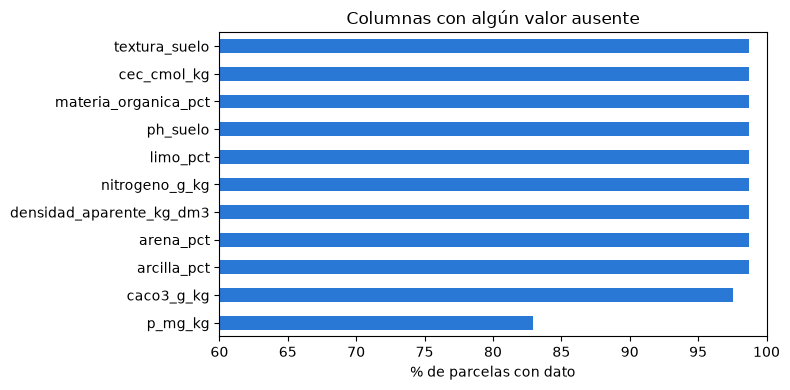

In [18]:
cobertura = parcelas_features.notna().mean()
cobertura_incompleta = (cobertura[cobertura < 1] * 100).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
cobertura_incompleta.plot.barh(ax=ax, color=AZUL)
ax.set_xlabel("% de parcelas con dato")
ax.set_xlim(60, 100)
ax.set_title("Columnas con algún valor ausente")
plt.tight_layout()
plt.show()

**Dispersión y concentración de la matriz.** A continuación se analiza la matriz de interacción: cuántos cultivos del catálogo declara cada parcela, cómo se distribuye el *score* de confianza y qué cultivos aparecen en más parcelas. Esto es importante porque, si unos pocos cultivos concentran la mayoría de las parcelas, un modelo que recomendara siempre esos cultivos obtendría un acierto aparentemente bueno sin haber aprendido nada. Por eso, en la evaluación se incluyen métricas de control que detectan ese comportamiento.

Parcelas según su nº de cultivos distintos del catálogo:
0      3025
1    119428
2     59256
3     17513
4       636
5       117
6        20
7         4
8         1


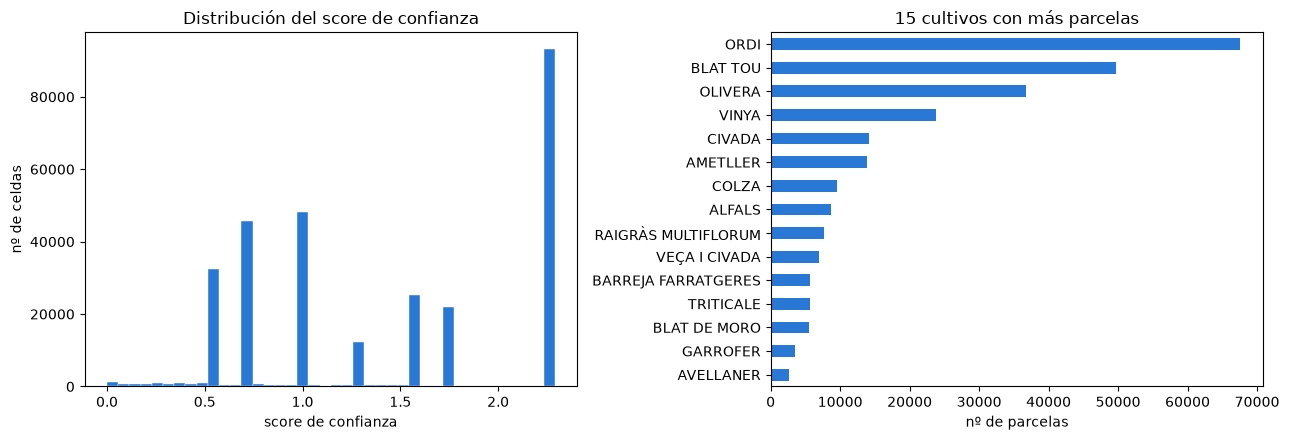

In [19]:
cultivos_por_parcela = np.diff(matriz_confianza.indptr)
print("Parcelas según su nº de cultivos distintos del catálogo:")
print(pd.Series(cultivos_por_parcela).value_counts().sort_index().to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.hist(matriz_confianza.data, bins=40, color=AZUL, edgecolor="white", linewidth=0.3)
ax1.set_xlabel("score de confianza")
ax1.set_ylabel("nº de celdas")
ax1.set_title("Distribución del score de confianza")

parcelas_por_cultivo = pd.Series(np.asarray((matriz_confianza > 0).sum(axis=0)).ravel(),
                                 index=cultivos_base["nombre_cultivo"]).sort_values(ascending=False)
parcelas_por_cultivo.head(15).sort_values().plot.barh(ax=ax2, color=AZUL)
ax2.set_xlabel("nº de parcelas")
ax2.set_ylabel("")
ax2.set_title("15 cultivos con más parcelas")
plt.tight_layout()
plt.show()

**Distribución de las variables numéricas.** En esta celda se muestran los histogramas de las principales variables numéricas. La superficie se representa en escala logarítmica porque hay muchas parcelas pequeñas y muy pocas grandes; ese mismo motivo explica que, en el preprocesado, se le aplique una transformación logarítmica. En las variables de clima y de nutrientes se repiten muchos valores, porque proceden de una red de estaciones y de un muestreo de campo disperso, y todas las parcelas cercanas comparten el mismo dato.

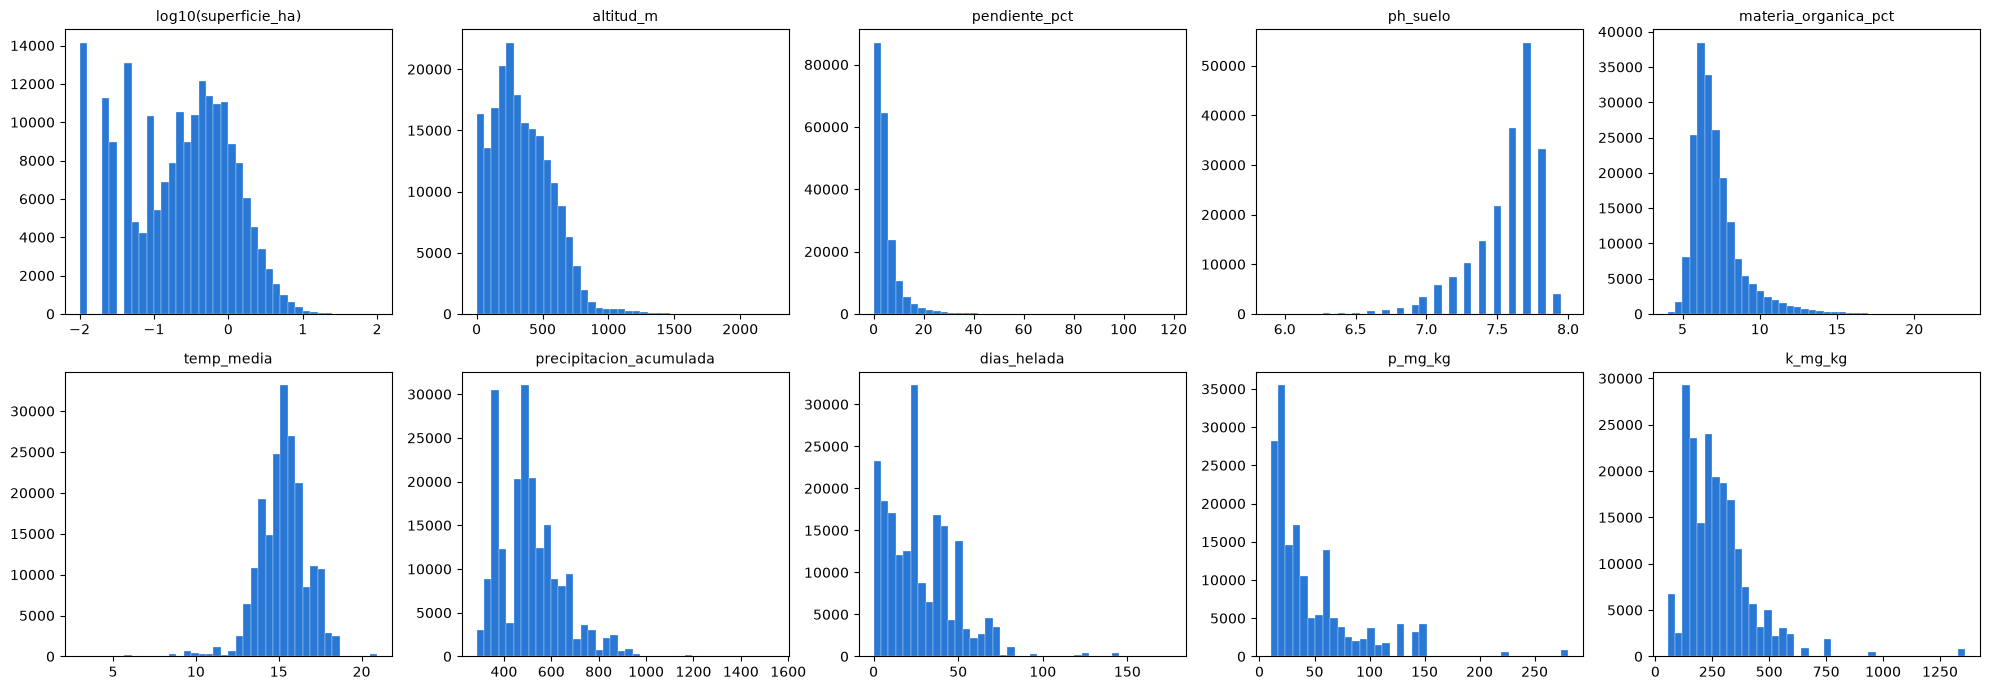

,count,mean,std,min,25%,50%,75%,max
superficie_ha,200000.0,0.64,1.19,0.00,0.06,0.27,0.76,100.08
altitud_m,200000.0,347.53,223.17,0.00,180.00,315.00,498.00,2257.00
pendiente_pct,200000.0,4.78,4.96,0.00,1.91,3.36,5.84,119.00
ph_suelo,197485.0,7.56,0.24,5.90,7.50,7.60,7.70,8.00
materia_organica_pct,197485.0,7.20,1.66,4.03,6.14,6.79,7.74,23.29
temp_media,200000.0,15.30,1.46,2.98,14.44,15.30,16.22,20.94
precipitacion_acumulada,200000.0,511.06,130.68,284.71,396.15,488.43,586.39,1540.44
dias_helada,200000.0,27.56,20.55,0.00,12.09,24.09,40.00,175.85
p_mg_kg,165880.0,47.06,40.82,10.10,19.80,31.20,60.60,280.50
k_mg_kg,200000.0,274.60,149.34,53.70,173.20,249.60,330.10,1360.30


In [20]:
numericas_eda = ["superficie_ha", "altitud_m", "pendiente_pct", "ph_suelo", "materia_organica_pct",
                 "temp_media", "precipitacion_acumulada", "dias_helada", "p_mg_kg", "k_mg_kg"]

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, columna in zip(axes.ravel(), numericas_eda):
    datos = parcelas_features[columna].dropna()
    if columna == "superficie_ha":
        datos, columna = np.log10(datos[datos > 0]), "log10(superficie_ha)"
    ax.hist(datos, bins=40, color=AZUL, edgecolor="white", linewidth=0.2)
    ax.set_title(columna, fontsize=10)
plt.tight_layout()
plt.show()

parcelas_features[numericas_eda].describe().T.round(2)

**Régimen de riego, textura del suelo y distribución espacial.** Aquí se representan cuántas parcelas hay de cada régimen de riego y de cada textura de suelo, y un mapa con la posición de las parcelas de la muestra según su régimen. El mapa permite comprobar a simple vista que la muestra cubre todo el territorio y que el regadío aparece en las zonas donde cabe esperarlo.

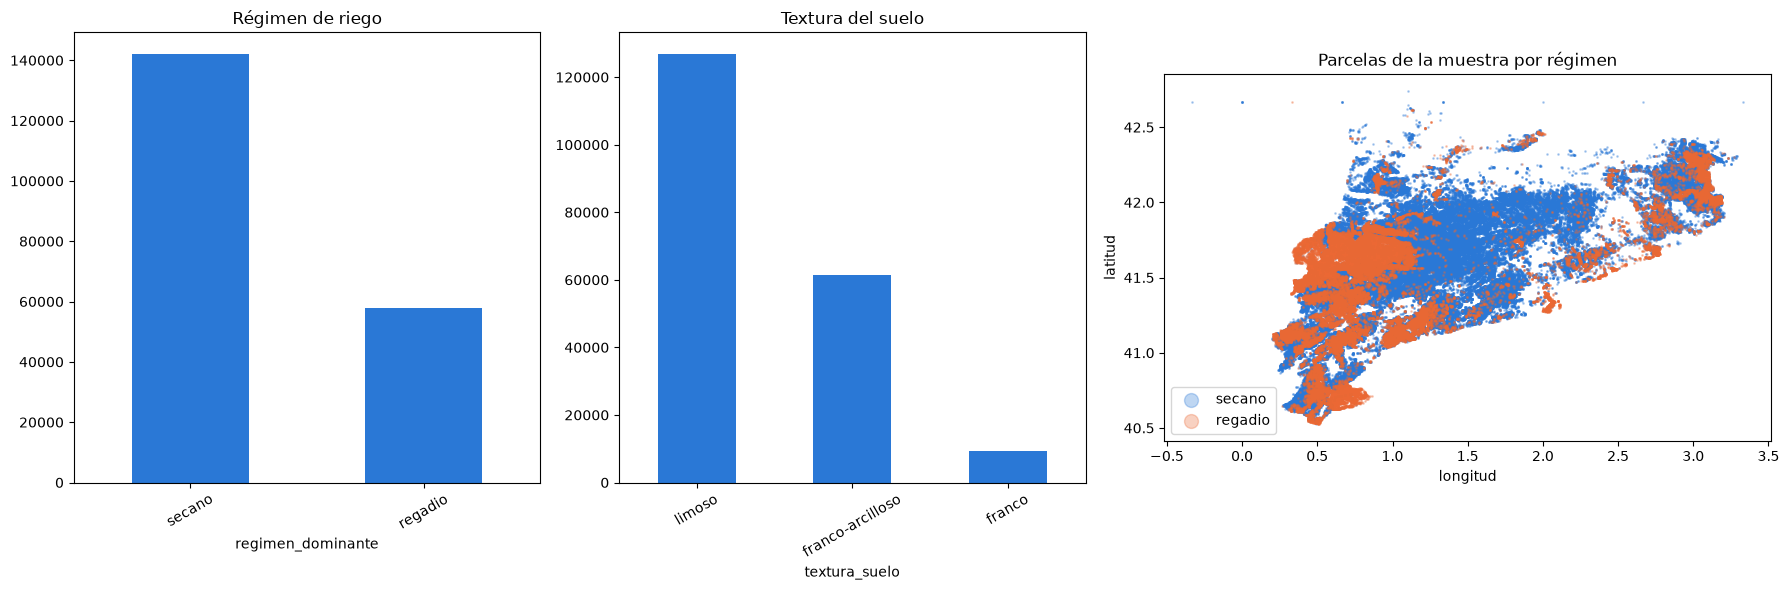

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={"width_ratios": [1, 1, 1.3]})
parcelas_features["regimen_dominante"].value_counts().plot.bar(ax=axes[0], color=AZUL)
axes[0].set_title("Régimen de riego")
parcelas_features["textura_suelo"].value_counts().plot.bar(ax=axes[1], color=AZUL)
axes[1].set_title("Textura del suelo")
for ax in axes[:2]:
    ax.tick_params(axis="x", rotation=30)

for regimen, color in {"secano": AZUL, "regadio": NARANJA}.items():
    sub = parcelas_features[parcelas_features["regimen_dominante"] == regimen]
    axes[2].scatter(sub["lon"], sub["lat"], s=1, alpha=0.3, color=color, label=regimen)
axes[2].set_aspect("equal")
axes[2].set_xlabel("longitud")
axes[2].set_ylabel("latitud")
axes[2].set_title("Parcelas de la muestra por régimen")
axes[2].legend(markerscale=10, loc="lower left")
plt.tight_layout()
plt.show()

**Correlaciones.** En esta celda se calcula la correlación entre las variables numéricas, es decir, en qué medida varían juntas. Es de esperar que las variables de clima estén muy relacionadas con la altitud (a más altitud, menos temperatura y más días de helada). No se elimina ninguna variable por estar correlacionada con otra, ya que ni los modelos de árboles ni LightFM se ven perjudicados por ello.

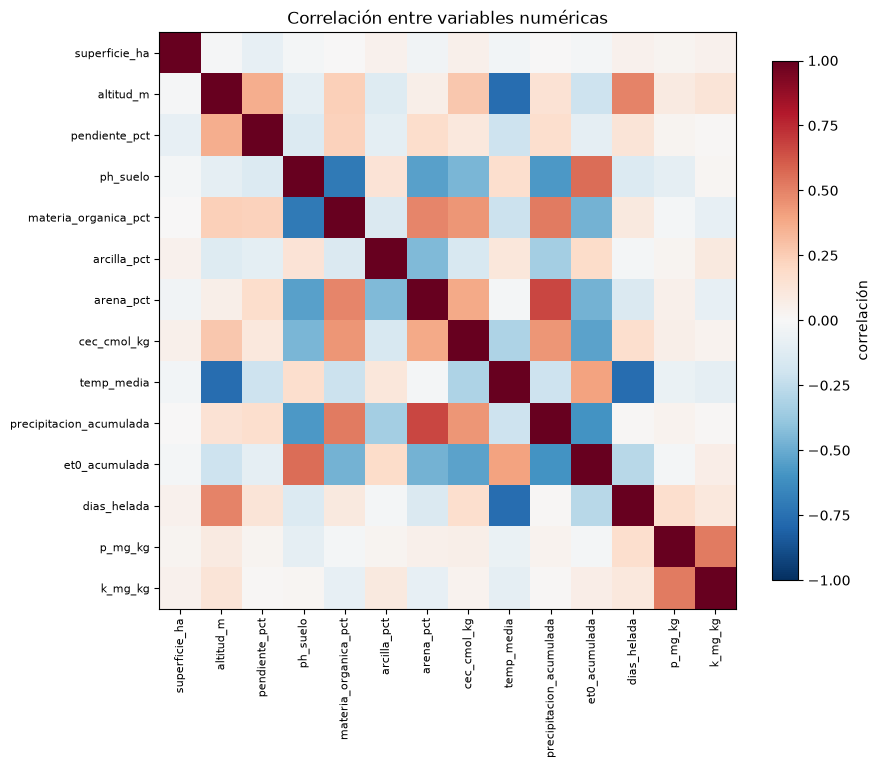

In [22]:
columnas_corr = ["superficie_ha", "altitud_m", "pendiente_pct", "ph_suelo", "materia_organica_pct",
                 "arcilla_pct", "arena_pct", "cec_cmol_kg", "temp_media", "precipitacion_acumulada",
                 "et0_acumulada", "dias_helada", "p_mg_kg", "k_mg_kg"]
corr = parcelas_features[columnas_corr].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(columnas_corr)), columnas_corr, rotation=90, fontsize=8)
ax.set_yticks(range(len(columnas_corr)), columnas_corr, fontsize=8)
fig.colorbar(im, ax=ax, label="correlación", shrink=0.8)
ax.set_title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()

**Coherencia agronómica.** Por último, se comprueba que los datos tienen sentido desde el punto de vista agronómico. Si el cruce entre la declaración y el clima es correcto, cada cultivo debería aparecer en su rango de temperaturas habitual: por ejemplo, los cereales de invierno de secano en las zonas más frías del interior y los cultivos que necesitan más calor en las zonas más cálidas.

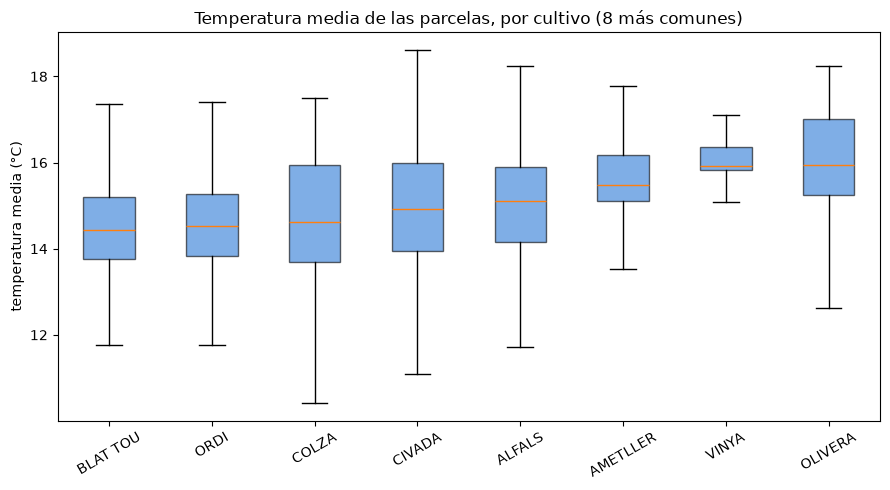

In [23]:
# Coherencia agronómica: temperatura media de las parcelas de los ocho cultivos más comunes
coo = matriz_confianza.tocoo()
largo = pd.DataFrame({"nombre_cultivo": cultivos_base["nombre_cultivo"].to_numpy()[coo.col],
                      "temp_media": parcelas_features["temp_media"].to_numpy()[coo.row]})
top8 = largo["nombre_cultivo"].value_counts().head(8).index
orden = largo[largo["nombre_cultivo"].isin(top8)].groupby("nombre_cultivo")["temp_media"].median().sort_values().index

fig, ax = plt.subplots(figsize=(9, 5))
cajas = ax.boxplot([largo.loc[largo["nombre_cultivo"] == c, "temp_media"].dropna() for c in orden],
                   tick_labels=orden, patch_artist=True, showfliers=False)
for caja in cajas["boxes"]:
    caja.set_facecolor(AZUL)
    caja.set_alpha(0.6)
ax.set_ylabel("temperatura media (°C)")
ax.set_title("Temperatura media de las parcelas, por cultivo (8 más comunes)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# 3. Núcleo recomendador: preprocesado, métricas y modelos

En esta parte se prepara todo lo necesario para entrenar y evaluar los modelos: el preprocesado de la tabla de características, las métricas de evaluación y las ocho variantes que se comparan.

**Preprocesado.** La tabla de características no se puede utilizar tal cual, porque sus columnas tienen escalas muy distintas, algunas tienen huecos y otras no son numéricas. Por ello, se aplican los siguientes pasos:

- **Variables numéricas.** A la superficie se le aplica primero una transformación logarítmica, $\log(1+x)$, para reducir el efecto de las pocas parcelas muy grandes. Después, los huecos se rellenan con la mediana de la columna y todas las variables se tipifican (se les resta la media y se dividen por la desviación típica), para que ninguna pese más que otra solo por su escala.
- **Variables categóricas** (régimen de riego y textura del suelo). Se codifican mediante *one-hot encoding*, es decir, con una columna de ceros y unos por cada categoría posible. Los huecos no se rellenan, sino que pasan a ser una categoría más.

Es importante tener en cuenta que las medianas, medias y desviaciones típicas se calculan siempre solo con las parcelas de entrenamiento, para que no se filtre información de las parcelas de evaluación. El resultado se obtiene en dos formatos equivalentes: uno disperso, que es el que necesita LightFM, y otro denso, que es el que necesitan los modelos de árboles.

In [24]:
COLUMNAS_NUMERICAS = [
    "superficie_ha", "lon", "lat", "altitud_m", "pendiente_pct",
    "arcilla_pct", "arena_pct", "limo_pct", "ph_suelo", "densidad_aparente_kg_dm3",
    "nitrogeno_g_kg", "cec_cmol_kg", "materia_organica_pct",
    "temp_media", "precipitacion_acumulada", "et0_acumulada", "dias_helada",
    "p_mg_kg", "k_mg_kg", "caco3_g_kg",
]
COLUMNAS_NUMERICAS_SIN_LONLAT = [c for c in COLUMNAS_NUMERICAS if c not in ("lon", "lat")]
COLUMNAS_CATEGORICAS = ["regimen_dominante", "textura_suelo"]


def fit_preprocessor(df, columnas_numericas=COLUMNAS_NUMERICAS):
    numericas = df[columnas_numericas].copy()
    numericas["superficie_ha"] = np.log1p(numericas["superficie_ha"])
    medianas = numericas.median()
    imputadas = numericas.fillna(medianas)
    categorias = {c: sorted(df[c].fillna("sin_dato").astype(str).unique()) for c in COLUMNAS_CATEGORICAS}
    return {"columnas_numericas": list(columnas_numericas), "medianas": medianas, "medias": imputadas.mean(),
            "stds": imputadas.std().replace(0, 1.0), "categorias": categorias, "n_filas_fit": len(df)}


def transform_features(df, prep):
    numericas = df[prep["columnas_numericas"]].copy()
    numericas["superficie_ha"] = np.log1p(numericas["superficie_ha"])
    numericas = (numericas.fillna(prep["medianas"]) - prep["medias"]) / prep["stds"]
    dummies = [pd.get_dummies(pd.Categorical(df[c].fillna("sin_dato").astype(str), categories=cats),
                              prefix=c, dtype=np.float32)
               for c, cats in prep["categorias"].items()]
    denso = pd.concat([numericas.astype(np.float32).reset_index(drop=True)] + dummies, axis=1)
    return sp.csr_matrix(denso.to_numpy()), denso.to_numpy(dtype=np.float32), denso.columns.tolist()


def preparar_features(df, columnas_numericas=COLUMNAS_NUMERICAS):
    """Ajuste y transformación sobre la misma tabla: solo cuando no hay partición que proteger."""
    return transform_features(df, fit_preprocessor(df, columnas_numericas))


parcela_ids = parcelas_base["parcela_id"].to_numpy()
cultivo_codigos = cultivos_base["codigo_producto"].to_numpy()
idx_parcela = {p: i for i, p in enumerate(parcela_ids)}
n_parcelas, n_cultivos = matriz_confianza.shape

**Métricas** (tabla 3.4 de la memoria). A continuación se definen las métricas de evaluación. Todas parten de la misma idea: el modelo ordena los 50 cultivos para cada parcela, y se compara ese orden con lo que la parcela declaró realmente. Como una parcela puede tener varios cultivos y no todos igual de importantes, las métricas admiten varios cultivos correctos por parcela, cada uno con su peso.

- **Precisión@k**: de los $k$ primeros cultivos recomendados, qué fracción declaró la parcela.
- **Exhaustividad@k**: de los cultivos que declaró la parcela, qué fracción aparece entre los $k$ primeros.
- **MAP@k**: tiene en cuenta además en qué posición aparecen los aciertos, de modo que acertar en los primeros puestos vale más.
- **NDCG@k**: similar a la anterior, pero además da más valor a acertar los cultivos que ocupan más superficie. Es la métrica principal de calidad del orden.
- **AUC**: probabilidad de que un cultivo declarado quede por encima de uno no declarado. Se calcula sobre el catálogo completo y no depende de $k$.
- **Cobertura@k** y **Concentración@k**: son métricas de control. La primera mide qué parte del catálogo llega a recomendarse, y la segunda, qué parte de las recomendaciones se concentra en los tres cultivos más frecuentes.

Cuando dos cultivos tienen exactamente la misma puntuación, se deshace el empate con un ruido aleatorio mínimo, para que no quede siempre por delante el que aparece antes en la tabla.

In [25]:
KS = (1, 3, 5, 10)


def rankear(scores, seed=42):
    ruido = np.random.default_rng(seed).uniform(0.0, 1e-9, size=scores.shape)  # desempate sin sesgo de columna
    return np.argsort(-(scores + ruido), axis=1, kind="stable")


def precision_at_k(orden, rel_binary, k):
    return float(np.mean(np.take_along_axis(rel_binary, orden[:, :k], axis=1).sum(axis=1) / k))


def recall_at_k(orden, rel_binary, k):
    hits = np.take_along_axis(rel_binary, orden[:, :k], axis=1).sum(axis=1)
    return float(np.mean(hits / np.clip(rel_binary.sum(axis=1), 1, None)))


def map_at_k(orden, rel_binary, k):
    hits = np.take_along_axis(rel_binary, orden[:, :k], axis=1)
    precision_i = np.cumsum(hits, axis=1) / np.arange(1, k + 1)[None, :]
    denom = np.clip(np.minimum(k, rel_binary.sum(axis=1)), 1, None)
    return float(np.mean((precision_i * hits).sum(axis=1) / denom))


def ndcg_at_k(orden, rel_weight, k):
    descuentos = 1.0 / np.log2(np.arange(2, k + 2))[None, :]
    dcg = (np.take_along_axis(rel_weight, orden[:, :k], axis=1) * descuentos).sum(axis=1)
    idcg = (-np.sort(-rel_weight, axis=1)[:, :k] * descuentos).sum(axis=1)
    return float(np.mean(dcg / np.clip(idcg, 1e-12, None)))


def auc(scores, rel_binary, seed=42):
    s = scores + np.random.default_rng(seed).uniform(0.0, 1e-9, size=scores.shape)
    rangos = np.empty_like(s)
    rangos[np.arange(s.shape[0])[:, None], np.argsort(s, axis=1)] = np.arange(1, s.shape[1] + 1)[None, :]
    n_pos = rel_binary.sum(axis=1)
    n_neg = rel_binary.shape[1] - n_pos
    valido = (n_pos > 0) & (n_neg > 0)
    auc_fila = ((rangos * rel_binary).sum(axis=1) - n_pos * (n_pos + 1) / 2) / np.where(valido, n_pos * n_neg, 1)
    return float(np.mean(auc_fila[valido]))


def evaluar(scores, filas, rel_binary_full, rel_weight_full, ks=KS, seed=42, idx_top3=None):
    rel_bin = rel_binary_full[filas].toarray()
    rel_w = rel_weight_full[filas].toarray()
    s = scores[filas] if scores.ndim == 2 else np.tile(scores, (len(filas), 1))
    orden = rankear(s, seed=seed)
    r = {"n_parcelas": int(len(filas))}
    for k in ks:
        r[f"precision@{k}"] = precision_at_k(orden, rel_bin, k)
        r[f"recall@{k}"] = recall_at_k(orden, rel_bin, k)
        r[f"map@{k}"] = map_at_k(orden, rel_bin, k)
        r[f"ndcg@{k}"] = ndcg_at_k(orden, rel_w, k)
        r[f"cobertura@{k}"] = len(np.unique(orden[:, :k])) / s.shape[1]          # control
        if idx_top3 is not None:
            r[f"concentracion@{k}"] = float(np.isin(orden[:, :k], idx_top3).mean())  # control
    r["auc"] = auc(s, rel_bin, seed=seed)
    return r

**Las ocho variantes** (tabla 4.1 de la memoria). En la siguiente celda se definen los ocho modelos que se van a comparar:

- **Popularidad** y **Aleatorio**, que son las referencias mínimas. Popularidad recomienda a todas las parcelas los cultivos con mayor *score* total, y Aleatorio ordena los cultivos al azar.
- **CF puro**, **Contenido puro** e **Híbrido**, las tres configuraciones de LightFM. LightFM representa cada parcela y cada cultivo mediante un *embedding*, que es un vector de números aprendido a partir de los datos, y puntúa cada par parcela-cultivo según lo parecidos que sean sus vectores. La diferencia entre las tres configuraciones está en qué información se usa para construir el vector de la parcela: solo su identidad (CF puro), solo su tabla de características (Contenido puro), o ambas a la vez (Híbrido). La identidad de cada parcela se representa con una columna propia que solo vale 1 para ella, lo que permite al modelo aprender un vector específico a partir de su historial.
- **Random Forest** y **XGBoost**, dos clasificadores de árboles que aprenden a predecir el cultivo principal de cada parcela a partir de sus características.
- **ALS**, la factorización matricial clásica para este tipo de datos, que solo aprende del historial.

LightFM se entrena con la pérdida WARP, que se centra en colocar bien los primeros puestos de la lista, y con el *score* de confianza como peso de cada observación: la matriz binaria indica qué pares parcela-cultivo existen, y el *score* indica cuánto pesa cada uno durante el entrenamiento.

La celda incluye también las funciones para buscar los hiperparámetros de cada variante, que son los valores que se fijan antes de entrenar (por ejemplo, el tamaño de los *embeddings* o la profundidad de los árboles). Para cada modelo se prueban dos valores por hiperparámetro y se elige la combinación con mejor MAP@5 en la partición de validación. En el caso de Random Forest y XGBoost, la etiqueta de cada parcela es su cultivo dominante, y la probabilidad que asignan a cada cultivo se utiliza como puntuación para ordenar el catálogo.

In [26]:
SEED = 42


def scores_popularidad(train):
    return np.asarray(train.sum(axis=0)).ravel()


def scores_aleatorio(n_filas, n_items, seed=SEED):
    return np.random.default_rng(seed).uniform(0, 1, size=(n_filas, n_items))


def entrenar_lightfm(train, user_features, item_features, no_components, learning_rate, epochs=15, seed=SEED):
    coo = train.tocoo()
    binaria = sp.coo_matrix((np.ones_like(coo.data, dtype=np.float32), (coo.row, coo.col)), shape=coo.shape)
    pesos = sp.coo_matrix((coo.data.astype(np.float32), (coo.row, coo.col)), shape=coo.shape)
    modelo = LightFM(no_components=no_components, learning_rate=learning_rate, loss="warp", random_state=seed)
    modelo.fit(binaria, user_features=user_features, item_features=item_features,
               sample_weight=pesos, epochs=epochs, num_threads=4, verbose=False)
    return modelo


def scores_lightfm(modelo, user_features, item_features):
    """bias_u + bias_i + emb_u · emb_i para todas las parcelas y cultivos a la vez."""
    ub, ue = modelo.get_user_representations(user_features)
    ib, ie = modelo.get_item_representations(item_features)
    return (ub[:, None] + ib[None, :] + ue @ ie.T).astype(np.float64)


def entrenar_arbol(clase, train, feat_denso, **kwargs):
    """Clasificador multiclase: la etiqueta es el cultivo dominante en entrenamiento."""
    filas_con_dato = np.where(np.diff(train.tocsr().indptr) > 0)[0]
    etiquetas = np.asarray(train[filas_con_dato].argmax(axis=1)).ravel()
    modelo = clase(**kwargs)
    if clase is XGBClassifier:  # exige etiquetas contiguas 0..k-1
        codificador = LabelEncoder()
        modelo.fit(feat_denso[filas_con_dato], codificador.fit_transform(etiquetas))
        modelo.clases_originales_ = codificador.classes_
    else:
        modelo.fit(feat_denso[filas_con_dato], etiquetas)
    return modelo


def scores_arbol(modelo, feat_denso, n_items):
    proba = modelo.predict_proba(feat_denso)
    scores = np.zeros((feat_denso.shape[0], n_items))
    scores[:, getattr(modelo, "clases_originales_", modelo.classes_)] = proba
    return scores


def entrenar_als(train, factors, regularization, alpha, iterations=15, seed=SEED):
    modelo = AlternatingLeastSquares(factors=factors, regularization=regularization, alpha=alpha,
                                     iterations=iterations, random_state=seed)
    modelo.fit(train, show_progress=False)
    return modelo


def scores_als(modelo):
    return np.asarray(modelo.user_factors @ modelo.item_factors.T)  # sin término de sesgo


# Rejilla de hiperparámetros (tabla 4.2); selección por MAP@5 en validación
GRID_LIGHTFM = [(nc, lr) for nc in (20, 50) for lr in (0.01, 0.05)]
GRID_RF_MAX_DEPTH, GRID_XGB_MAX_DEPTH = (12, 20), (6, 10)
GRID_ALS = [(f, r, a) for f in (20, 50) for r in (0.01, 0.1) for a in (1.0, 40.0)]
KW_RF = dict(n_estimators=100, n_jobs=-1)
KW_XGB = dict(n_estimators=150, objective="multi:softprob", n_jobs=4, eval_metric="mlogloss")


def _map5(scores, filas_val, rel_val):
    return evaluar(scores, filas_val, rel_val, rel_val, ks=(5,))["map@5"]


def _mejor(candidatos, puntuar):
    """Primer candidato con el mayor MAP@5 (en caso de empate exacto se queda el primero de la rejilla)."""
    mejor, mejor_m = None, -np.inf
    for c in candidatos:
        m = puntuar(c)
        if m > mejor_m:
            mejor, mejor_m = c, m
    return mejor, mejor_m


def buscar_lightfm(train, uf, itf, filas_val, rel_val, nombre):
    (nc, lr), m = _mejor(GRID_LIGHTFM, lambda c: _map5(
        scores_lightfm(entrenar_lightfm(train, uf, itf, *c), uf, itf), filas_val, rel_val))
    print(f"  {nombre:15s} no_components={nc} learning_rate={lr} (MAP@5 val={m:.4f})")
    return {"no_components": nc, "learning_rate": lr}


def buscar_arbol(clase, train, grid, filas_val, rel_val, nombre, feat_denso, n_items, **kw):
    d, m = _mejor(grid, lambda d: _map5(scores_arbol(
        entrenar_arbol(clase, train, feat_denso, max_depth=d, random_state=SEED, **kw), feat_denso, n_items),
        filas_val, rel_val))
    print(f"  {nombre:15s} max_depth={d} (MAP@5 val={m:.4f})")
    return d


def buscar_als(train, filas_val, rel_val, nombre):
    (f, r, a), m = _mejor(GRID_ALS, lambda c: _map5(scores_als(entrenar_als(train, *c)), filas_val, rel_val))
    print(f"  {nombre:15s} factors={f} regularization={r} alpha={a} (MAP@5 val={m:.4f})")
    return {"factors": f, "regularization": r, "alpha": a}


NOMBRES_MODELOS = ["Popularidad", "Aleatorio", "CF puro", "Contenido puro", "Híbrido", "Random Forest", "XGBoost", "ALS"]

# 4. Escenario A: generalización temporal

El primer escenario de evaluación responde a la pregunta del uso habitual: conociendo el historial de una parcela hasta hoy, ¿acierta el sistema lo que declarará en la próxima campaña? Para ello, los modelos se entrenan con las campañas 2023 y 2024 y se evalúan con lo que se declaró en 2025.

Para que la evaluación sea honesta, ningún dato utilizado en el entrenamiento puede depender de la campaña 2025. Por eso, se rehacen algunas piezas del conjunto de datos:

- El régimen de riego, la superficie y la pendiente se toman de la declaración más reciente anterior a 2025.
- El catálogo de cultivos se recalcula con la superficie declarada en 2023-2024.
- La normal climatológica se recalcula con los años 2018-2024.
- La longitud y la latitud se excluyen, porque la posición de cada parcela se calculó a partir de su geometría de 2025.

En la siguiente celda se descargan las declaraciones de 2023-2024 necesarias para ello y se recalcula el catálogo.

In [27]:
COLUMNAS_EXANTE = ["ID_REC", "CAMPANYA", "CPROD", "NPROD", "SUP_DEC_H", "SUP_NETA_H", "SIST_EXPL", "PENDENT", "GRUP_NOM"]
ANIOS_EXANTE = [a for a in CAMPANYES if a < ANIO_REFERENCIA]

declaraciones_exante = pd.concat(
    [descargar_atributos_muestra(a, ids_muestra, COLUMNAS_EXANTE, "parcels_cultius_muestra_exante") for a in ANIOS_EXANTE],
    ignore_index=True)
for col in ["CPROD", "SUP_DEC_H", "SUP_NETA_H", "PENDENT"]:
    declaraciones_exante[col] = pd.to_numeric(declaraciones_exante[col], errors="coerce")
declaraciones_exante["CAMPANYA"] = declaraciones_exante["CAMPANYA"].astype(int)
assert declaraciones_exante["CAMPANYA"].max() < ANIO_REFERENCIA

# Régimen, superficie y pendiente de la campaña más reciente <= 2024 de cada parcela
recintos_exante = (declaraciones_exante.sort_values(["ID_REC", "CAMPANYA"], ascending=[True, False])
                   .drop_duplicates("ID_REC")
                   .rename(columns={"ID_REC": "parcela_id", "SUP_NETA_H": "superficie_ha", "PENDENT": "pendiente_pct"}))
recintos_exante["regimen_dominante"] = recintos_exante["SIST_EXPL"].map(clasificar_regimen)
regimen_superficie_a = parcelas_base[["parcela_id"]].merge(
    recintos_exante[["parcela_id", "superficie_ha", "pendiente_pct", "regimen_dominante"]], on="parcela_id", how="left")
regimen_superficie_a["regimen_dominante"] = regimen_superficie_a["regimen_dominante"].fillna("sin_dato")
pendiente_a = completar_pendiente(regimen_superficie_a, altitud_pendiente)

# Catálogo temporal: mismo criterio que el original, con la superficie de 2023-2024
ranking_a = (declaraciones_exante[~declaraciones_exante["GRUP_NOM"].isin(GRUPOS_NO_CULTIU)]
             .groupby(["CPROD", "NPROD"])["SUP_DEC_H"].sum().rename("ha_total").reset_index())
catalogo_a = (ranking_a.nlargest(limite_cultivos, "ha_total").reset_index(drop=True)
              .rename(columns={"CPROD": "codigo_producto", "NPROD": "nombre_cultivo"}))
print(f"Catálogo temporal: {len(catalogo_a)} cultivos, "
      f"{len(set(catalogo_a['codigo_producto']) & set(catalogo_cultius['codigo_producto']))} en común con el de 2025")

Catálogo temporal: 50 cultivos, 48 en común con el de 2025


**Matriz de entrenamiento, test y validación.** A continuación se construyen los tres conjuntos de datos del escenario:

- **Entrenamiento**: la matriz de interacción construida solo con 2023 y 2024.
- **Test**: lo que declaró cada parcela en 2025, con la fracción de superficie de cada cultivo como peso.
- **Validación**: sirve para elegir los hiperparámetros sin mirar 2025. Se entrena con 2023 y se comprueba si el modelo acierta el cultivo principal de 2024.

Las parcelas de test se separan además en dos grupos: las que tienen historial en 2023-2024 y las que no.

In [28]:
interacciones_a = construir_interacciones(catalogo_a)
matriz_train_a, _, cultivos_a = construir_matriz(catalogo_a, calcular_confianza(interacciones_a[interacciones_a["anio"] < ANIO_REFERENCIA]))
n_cultivos_a = matriz_train_a.shape[1]
idx_cultivo_a = {c: i for i, c in enumerate(cultivos_a["codigo_producto"])}

# Test: declaración de 2025, con la fracción de superficie como relevancia graduada
test_a = interacciones_a[(interacciones_a["anio"] == ANIO_REFERENCIA) & (interacciones_a["area_ha"] > 0)].copy()
test_a["fraccion"] = test_a["area_ha"] / test_a.groupby("parcela_id")["area_ha"].transform("sum")
test_a["fila"] = test_a["parcela_id"].map(idx_parcela)
test_a["columna"] = test_a["codigo_producto"].map(idx_cultivo_a)
rel_binary_a = sp.csr_matrix((np.ones(len(test_a), dtype=np.float32), (test_a["fila"], test_a["columna"])),
                             shape=(n_parcelas, n_cultivos_a))
rel_weight_a = sp.csr_matrix((test_a["fraccion"].astype(np.float32), (test_a["fila"], test_a["columna"])),
                             shape=(n_parcelas, n_cultivos_a))

filas_test_a = np.sort(test_a["fila"].unique())
con_historial_a = filas_test_a[np.diff(matriz_train_a.indptr)[filas_test_a] > 0]
sin_historial_a = filas_test_a[np.diff(matriz_train_a.indptr)[filas_test_a] == 0]

# Validación anidada: entrena con 2023, valida contra el cultivo dominante de 2024
sub_a = interacciones_a[interacciones_a["anio"] <= 2023].copy()
sub_a["peso"] = np.exp(-LAMBDA_RECENCIA * (2023 - sub_a["anio"]))
sub_a = sub_a.groupby(["parcela_id", "codigo_producto"], as_index=False)["peso"].sum()
train_val_a = sp.csr_matrix((sub_a["peso"].astype(np.float32),
                             (sub_a["parcela_id"].map(idx_parcela), sub_a["codigo_producto"].map(idx_cultivo_a))),
                            shape=(n_parcelas, n_cultivos_a))
val_2024 = interacciones_a[interacciones_a["anio"] == 2024].copy()
val_2024["fila"] = val_2024["parcela_id"].map(idx_parcela)
val_2024["columna"] = val_2024["codigo_producto"].map(idx_cultivo_a)
filas_val_a = np.sort(val_2024.loc[np.diff(train_val_a.indptr)[val_2024["fila"]] > 0, "fila"].unique())
dominante_2024 = val_2024.sort_values("area_ha", ascending=False).drop_duplicates("fila").set_index("fila")["columna"]
rel_val_a = sp.csr_matrix((np.ones(len(filas_val_a), dtype=np.float32), (filas_val_a, dominante_2024.loc[filas_val_a])),
                          shape=(n_parcelas, n_cultivos_a))

print(f"Entrenamiento: {matriz_train_a.nnz:,} celdas no vacías (2023-2024)")
print(f"Test 2025: {len(filas_test_a):,} parcelas evaluables "
      f"({len(con_historial_a):,} con historial, {len(sin_historial_a):,} sin historial)")
print(f"Validación (2023 -> 2024): {len(filas_val_a):,} parcelas")

Matriz 200,000 x 50 (243,307 celdas no vacías, densidad 2.43%)


Entrenamiento: 243,307 celdas no vacías (2023-2024)
Test 2025: 195,335 parcelas evaluables (183,986 con historial, 11,349 sin historial)
Validación (2023 -> 2024): 162,284 parcelas


**Características *ex ante*.** En esta celda se reconstruye la tabla de características del escenario A sin utilizar nada de 2025, tal y como se ha explicado al comienzo de la sección, y se le aplica el preprocesado. Una vez hecho esto, se liberan de la memoria los datos en bruto que ya no se necesitan.

In [29]:
clima_a = construir_clima(list(range(2018, 2025)))

parcelas_features_a = (parcelas_base
                       .merge(regimen_superficie_a.drop(columns=["pendiente_pct"]), on="parcela_id", how="left")
                       .merge(pendiente_a, on="parcela_id", how="left")
                       .merge(altitud, on="parcela_id", how="left")
                       .merge(suelo, on="parcela_id", how="left")
                       .merge(clima_a, on="parcela_id", how="left")
                       .merge(nutrientes, on="parcela_id", how="left"))

prep_a = fit_preprocessor(parcelas_features_a.iloc[con_historial_a], columnas_numericas=COLUMNAS_NUMERICAS_SIN_LONLAT)
feat_disperso_a, feat_denso_a, _ = transform_features(parcelas_features_a, prep_a)
print(f"Características del escenario A: {feat_denso_a.shape[1]} columnas "
      f"(preprocesador ajustado sobre {prep_a['n_filas_fit']:,} parcelas con historial)")

# Las lecturas diarias y las declaraciones en bruto ya no se necesitan
liberar("temp_diaria", "tmax_diaria", "tmin_diaria", "precip_diaria", "humitat_diaria", "vent_diaria",
        "radiacio_diaria", "declaraciones_exante", "declaraciones_muestra", "superficie_total_declarada", "recintos_exante", "interacciones_a", "sub_a", "val_2024", "test_a")

Características del escenario A: 24 columnas (preprocesador ajustado sobre 183,986 parcelas con historial)


**Búsqueda de hiperparámetros.** A continuación se eligen los hiperparámetros de cada variante (tabla 4.2 de la memoria). Para cada modelo se prueban dos valores por hiperparámetro y se elige la combinación con mejor MAP@5 en la validación anidada, entrenando con 2023 y validando contra 2024. De esta forma, la campaña de 2025 no interviene en ninguna decisión.

In [30]:
identidad_parcelas = sp.identity(n_parcelas, format="csr", dtype=np.float32)
identidad_items_a = sp.identity(n_cultivos_a, format="csr", dtype=np.float32)
feat_hibrido_a = sp.hstack([identidad_parcelas, feat_disperso_a], format="csr")

print("Escenario A -- búsqueda de hiperparámetros:")
hp_a = {
    "CF puro": buscar_lightfm(train_val_a, None, None, filas_val_a, rel_val_a, "CF puro"),
    "Contenido puro": buscar_lightfm(train_val_a, feat_disperso_a, identidad_items_a, filas_val_a, rel_val_a, "Contenido puro"),
    "Híbrido": buscar_lightfm(train_val_a, feat_hibrido_a, identidad_items_a, filas_val_a, rel_val_a, "Híbrido"),
    "Random Forest": buscar_arbol(RandomForestClassifier, train_val_a, GRID_RF_MAX_DEPTH, filas_val_a, rel_val_a,
                                  "Random Forest", feat_denso_a, n_cultivos_a, **KW_RF),
    "XGBoost": buscar_arbol(XGBClassifier, train_val_a, GRID_XGB_MAX_DEPTH, filas_val_a, rel_val_a,
                            "XGBoost", feat_denso_a, n_cultivos_a, **KW_XGB),
    "ALS": buscar_als(train_val_a, filas_val_a, rel_val_a, "ALS"),
}

Escenario A -- búsqueda de hiperparámetros:


  CF puro         no_components=50 learning_rate=0.05 (MAP@5 val=0.7390)


  Contenido puro  no_components=50 learning_rate=0.05 (MAP@5 val=0.5514)


  Híbrido         no_components=20 learning_rate=0.05 (MAP@5 val=0.7256)


  Random Forest   max_depth=20 (MAP@5 val=0.7610)


  XGBoost         max_depth=10 (MAP@5 val=0.7672)


  ALS             factors=50 regularization=0.01 alpha=1.0 (MAP@5 val=0.7175)


**Entrenamiento y evaluación.** Con los hiperparámetros ya elegidos, se entrenan las ocho variantes con 2023-2024 y se evalúan contra lo declarado en 2025. La evaluación se hace sobre tres grupos de parcelas: las que tienen historial en 2023-2024, las que no lo tienen (aparecen por primera vez con un cultivo del catálogo en 2025) y todas juntas.

In [31]:
pop_a = scores_popularidad(matriz_train_a)
idx_top3_a = np.argsort(-pop_a)[:3]

scores_a = {
    "Popularidad": pop_a,
    "Aleatorio": scores_aleatorio(n_parcelas, n_cultivos_a),
    "CF puro": scores_lightfm(entrenar_lightfm(matriz_train_a, None, None, **hp_a["CF puro"]), None, None),
    "Contenido puro": scores_lightfm(entrenar_lightfm(matriz_train_a, feat_disperso_a, identidad_items_a,
                                                      **hp_a["Contenido puro"]), feat_disperso_a, identidad_items_a),
    "Híbrido": scores_lightfm(entrenar_lightfm(matriz_train_a, feat_hibrido_a, identidad_items_a, **hp_a["Híbrido"]),
                              feat_hibrido_a, identidad_items_a),
    "Random Forest": scores_arbol(entrenar_arbol(RandomForestClassifier, matriz_train_a, feat_denso_a,
                                                 max_depth=hp_a["Random Forest"], random_state=SEED, **KW_RF),
                                  feat_denso_a, n_cultivos_a),
    "XGBoost": scores_arbol(entrenar_arbol(XGBClassifier, matriz_train_a, feat_denso_a,
                                           max_depth=hp_a["XGBoost"], random_state=SEED, **KW_XGB),
                            feat_denso_a, n_cultivos_a),
    "ALS": scores_als(entrenar_als(matriz_train_a, **hp_a["ALS"])),
}

POBLACIONES_A = {"con_historial": con_historial_a, "sin_historial": sin_historial_a, "agregado": filas_test_a}
resultados_a = {nombre: {pob: evaluar(s, filas, rel_binary_a, rel_weight_a, idx_top3=idx_top3_a)
                         for pob, filas in POBLACIONES_A.items()}
                for nombre, s in scores_a.items()}

liberar("scores_a", "feat_disperso_a", "feat_denso_a", "feat_hibrido_a", "train_val_a", "rel_val_a",
        "matriz_train_a", "rel_binary_a", "rel_weight_a", "parcelas_features_a")
pd.DataFrame({n: r["con_historial"] for n, r in resultados_a.items()}).T[
    ["precision@1", "recall@5", "ndcg@5", "map@5", "auc"]].round(4)

,precision@1,recall@5,ndcg@5,map@5,auc
Popularidad,0.2041,0.6879,0.4540,0.3763,0.8898
Aleatorio,0.0202,0.0996,0.0588,0.0455,0.4990
CF puro,0.6873,0.8747,0.7944,0.7668,0.9485
Contenido puro,0.3880,0.8157,0.6171,0.5507,0.9455
Híbrido,0.6990,0.9082,0.8165,0.7851,0.9688
Random Forest,0.6332,0.9245,0.7983,0.7543,0.9749
XGBoost,0.6452,0.9207,0.8014,0.7593,0.9747
ALS,0.6637,0.8884,0.7973,0.7659,0.9483


# 5. Escenario B: *cold start*

El segundo escenario responde a otra pregunta: ante una parcela nueva, de la que no se conoce ningún historial y solo se sabe cómo es su suelo, su relieve y su clima, ¿qué cultivos se le pueden recomendar? Es lo que se conoce como *cold start* o arranque en frío.

Para ello, las parcelas se reparten al azar en tres grupos: un 80 % para entrenamiento, un 10 % para validación y un 10 % para test. A las parcelas de validación y de test se les borra por completo su historial en la matriz de entrenamiento, de modo que los modelos no ven ninguna de sus interacciones. Después, se comprueba si los modelos aciertan su fila completa de la matriz de confianza.

En la siguiente celda se construye el primer reparto (con la semilla 42), se prepara la tabla de características y se buscan los hiperparámetros de cada variante.

In [32]:
rel_weight_b = matriz_confianza
rel_binary_b = matriz_confianza.copy()
rel_binary_b.data = np.ones_like(rel_binary_b.data)
identidad_items = sp.identity(n_cultivos, format="csr", dtype=np.float32)


def construir_split_b(seed, frac_train=0.8, frac_val=0.1):
    idx = np.random.default_rng(seed).permutation(n_parcelas)
    n_train, n_val = int(n_parcelas * frac_train), int(n_parcelas * frac_val)
    idx_train, idx_val, idx_test = (np.sort(idx[:n_train]), np.sort(idx[n_train:n_train + n_val]),
                                    np.sort(idx[n_train + n_val:]))
    mascara = np.ones(n_parcelas, dtype=np.float32)
    mascara[np.concatenate([idx_val, idx_test])] = 0.0
    return (sp.diags(mascara) @ matriz_confianza).tocsr(), idx_train, idx_val, idx_test


def features_b(idx_train):
    prep = fit_preprocessor(parcelas_features.iloc[idx_train])
    disperso, denso, _ = transform_features(parcelas_features, prep)
    return disperso, denso


train_b, idx_train_b, idx_val_b, idx_test_b = construir_split_b(SEED)
assert train_b[np.concatenate([idx_val_b, idx_test_b])].nnz == 0
print(f"Semilla {SEED} -- entrenamiento: {len(idx_train_b):,} · validación: {len(idx_val_b):,} · test: {len(idx_test_b):,}")

feat_disperso_b, feat_denso_b = features_b(idx_train_b)
feat_hibrido_b = sp.hstack([identidad_parcelas, feat_disperso_b], format="csr")

print("\nEscenario B -- búsqueda de hiperparámetros:")
hp_b = {
    "CF puro": buscar_lightfm(train_b, None, None, idx_val_b, rel_binary_b, "CF puro"),
    "Contenido puro": buscar_lightfm(train_b, feat_disperso_b, identidad_items, idx_val_b, rel_binary_b, "Contenido puro"),
    "Híbrido": buscar_lightfm(train_b, feat_hibrido_b, identidad_items, idx_val_b, rel_binary_b, "Híbrido"),
    "Random Forest": buscar_arbol(RandomForestClassifier, train_b, GRID_RF_MAX_DEPTH, idx_val_b, rel_binary_b,
                                  "Random Forest", feat_denso_b, n_cultivos, **KW_RF),
    "XGBoost": buscar_arbol(XGBClassifier, train_b, GRID_XGB_MAX_DEPTH, idx_val_b, rel_binary_b,
                            "XGBoost", feat_denso_b, n_cultivos, **KW_XGB),
    "ALS": buscar_als(train_b, idx_val_b, rel_binary_b, "ALS"),
}

Semilla 42 -- entrenamiento: 160,000 · validación: 20,000 · test: 20,000



Escenario B -- búsqueda de hiperparámetros:


  CF puro         no_components=50 learning_rate=0.01 (MAP@5 val=0.3837)


  Contenido puro  no_components=50 learning_rate=0.05 (MAP@5 val=0.5965)


  Híbrido         no_components=50 learning_rate=0.01 (MAP@5 val=0.5903)


  Random Forest   max_depth=20 (MAP@5 val=0.6987)


  XGBoost         max_depth=10 (MAP@5 val=0.6861)


  ALS             factors=20 regularization=0.01 alpha=1.0 (MAP@5 val=0.0451)


**Evaluación con diez semillas.** Como el reparto de las parcelas es aleatorio, el resultado podría depender de un reparto concreto. Para evitarlo, la evaluación se repite con diez semillas distintas, es decir, con diez repartos diferentes, y se calcula la media y la desviación típica de cada métrica. En cada repetición se vuelven a entrenar las ocho variantes con los hiperparámetros ya elegidos, por lo que esta es la celda más lenta del cuaderno.

In [33]:
resultados_b_por_semilla = {nombre: [] for nombre in NOMBRES_MODELOS}

for seed in range(10):
    train_b, idx_train_b, idx_val_b, idx_test_b = construir_split_b(seed)
    feat_disperso_b, feat_denso_b = features_b(idx_train_b)
    feat_hibrido_b = sp.hstack([identidad_parcelas, feat_disperso_b], format="csr")
    pop_b = scores_popularidad(train_b)

    m_cf = entrenar_lightfm(train_b, None, None, **hp_b["CF puro"], seed=seed)
    m_als = entrenar_als(train_b, **hp_b["ALS"], seed=seed)
    scores_b = {
        "Popularidad": pop_b,
        "Aleatorio": scores_aleatorio(n_parcelas, n_cultivos, seed=seed),
        "CF puro": scores_lightfm(m_cf, None, None),
        "Contenido puro": scores_lightfm(entrenar_lightfm(train_b, feat_disperso_b, identidad_items,
                                                         **hp_b["Contenido puro"], seed=seed),
                                         feat_disperso_b, identidad_items),
        "Híbrido": scores_lightfm(entrenar_lightfm(train_b, feat_hibrido_b, identidad_items, **hp_b["Híbrido"], seed=seed),
                                  feat_hibrido_b, identidad_items),
        "Random Forest": scores_arbol(entrenar_arbol(RandomForestClassifier, train_b, feat_denso_b,
                                                     max_depth=hp_b["Random Forest"], random_state=seed, **KW_RF),
                                      feat_denso_b, n_cultivos),
        "XGBoost": scores_arbol(entrenar_arbol(XGBClassifier, train_b, feat_denso_b,
                                               max_depth=hp_b["XGBoost"], random_state=seed, **KW_XGB),
                                feat_denso_b, n_cultivos),
        "ALS": scores_als(m_als),
    }
    for nombre, s in scores_b.items():
        resultados_b_por_semilla[nombre].append(
            evaluar(s, idx_test_b, rel_binary_b, rel_weight_b, seed=seed, idx_top3=np.argsort(-pop_b)[:3]))
    print(f"semilla {seed}: Híbrido NDCG@5={resultados_b_por_semilla['Híbrido'][-1]['ndcg@5']:.4f} · "
          f"Random Forest NDCG@5={resultados_b_por_semilla['Random Forest'][-1]['ndcg@5']:.4f}")
    del scores_b
    gc.collect()

resultados_b = {n: {"media": pd.DataFrame(l).mean(), "std": pd.DataFrame(l).std()}
                for n, l in resultados_b_por_semilla.items()}

semilla 0: Híbrido NDCG@5=0.6575 · Random Forest NDCG@5=0.7564


semilla 1: Híbrido NDCG@5=0.6565 · Random Forest NDCG@5=0.7579


semilla 2: Híbrido NDCG@5=0.6560 · Random Forest NDCG@5=0.7570


semilla 3: Híbrido NDCG@5=0.6572 · Random Forest NDCG@5=0.7553


semilla 4: Híbrido NDCG@5=0.6595 · Random Forest NDCG@5=0.7583


semilla 5: Híbrido NDCG@5=0.6595 · Random Forest NDCG@5=0.7586


semilla 6: Híbrido NDCG@5=0.6549 · Random Forest NDCG@5=0.7587


semilla 7: Híbrido NDCG@5=0.6584 · Random Forest NDCG@5=0.7579


semilla 8: Híbrido NDCG@5=0.6591 · Random Forest NDCG@5=0.7556


semilla 9: Híbrido NDCG@5=0.6538 · Random Forest NDCG@5=0.7566


**Colapso de los modelos colaborativos en frío** (sección 4.2.2 de la memoria). En esta celda se comprueba por qué los dos modelos que solo aprenden del historial (CF puro y ALS) no pueden recomendar a parcelas nuevas:

- **ALS** representa cada parcela con un vector que solo aprende de su historial. Como las parcelas de test no tienen historial, su vector se queda en cero y todos los cultivos reciben la misma puntuación, de modo que el orden lo decide el desempate aleatorio.
- **CF puro** añade a cada cultivo un sesgo propio, que refleja lo frecuente que es. Como ese sesgo no depende de la parcela, todas las parcelas nuevas reciben la misma lista, que coincide con la de Popularidad.

La comprobación se hace con los modelos de la última semilla.

In [34]:
print(f"Norma media de los factores ALS de las parcelas frías: "
      f"{np.linalg.norm(m_als.user_factors[idx_test_b], axis=1).mean():.8f} "
      f"(parcelas de entrenamiento: {np.linalg.norm(m_als.user_factors[idx_train_b], axis=1).mean():.4f})")

top1_pop = rankear(np.tile(pop_b, (len(idx_test_b), 1)), seed=0)[:, 0]
for nombre, s in [("ALS", scores_als(m_als)), ("CF puro", scores_lightfm(m_cf, None, None))]:
    coincide = (rankear(s[idx_test_b], seed=0)[:, 0] == top1_pop).mean()
    print(f"El top-1 de {nombre} coincide con el de Popularidad en las parcelas frías: {coincide:.2%}")
print(f"(al azar entre {n_cultivos} cultivos se esperaría {1 / n_cultivos:.2%})")

Norma media de los factores ALS de las parcelas frías: 0.00000000 (parcelas de entrenamiento: 1.8438)
El top-1 de ALS coincide con el de Popularidad en las parcelas frías: 2.07%
El top-1 de CF puro coincide con el de Popularidad en las parcelas frías: 100.00%
(al azar entre 50 cultivos se esperaría 2.00%)


# 6. Resultados del núcleo recomendador

En esta sección se recogen los resultados de la evaluación. En la siguiente celda se muestran las dos tablas principales de la memoria: la del escenario A, sobre las parcelas con historial (tabla 4.3), y la del escenario B, con la media y la desviación típica sobre las diez semillas (tabla 4.4).

In [35]:
COLS_A = {"precision@1": "P@1", "recall@5": "R@5", "ndcg@5": "NDCG@5", "map@5": "MAP@5",
          "cobertura@5": "Cob.@5", "concentracion@5": "Conc.@5", "auc": "AUC"}
tabla_a = pd.DataFrame({n: resultados_a[n]["con_historial"] for n in NOMBRES_MODELOS}).T[list(COLS_A)].rename(columns=COLS_A)
print(f"Escenario A -- parcelas con historial (n = {len(con_historial_a):,})")
display(tabla_a.round(4))

COLS_B = {"precision@1": "P@1", "recall@5": "R@5", "ndcg@5": "NDCG@5", "auc": "AUC"}
tabla_b = pd.DataFrame({n: {etq: f"{resultados_b[n]['media'][c]:.4f} ± {resultados_b[n]['std'][c]:.4f}"
                            for c, etq in COLS_B.items()} for n in NOMBRES_MODELOS}).T
print("Escenario B -- media ± desviación típica, 10 semillas")
display(tabla_b)

Escenario A -- parcelas con historial (n = 183,986)


,P@1,R@5,NDCG@5,MAP@5,Cob.@5,Conc.@5,AUC
Popularidad,0.2041,0.6879,0.4540,0.3763,0.10,0.6000,0.8898
Aleatorio,0.0202,0.0996,0.0588,0.0455,1.00,0.0598,0.4990
CF puro,0.6873,0.8747,0.7944,0.7668,1.00,0.2499,0.9485
Contenido puro,0.3880,0.8157,0.6171,0.5507,0.82,0.4301,0.9455
Híbrido,0.6990,0.9082,0.8165,0.7851,1.00,0.2048,0.9688
Random Forest,0.6332,0.9245,0.7983,0.7543,1.00,0.3418,0.9749
XGBoost,0.6452,0.9207,0.8014,0.7593,1.00,0.3664,0.9747
ALS,0.6637,0.8884,0.7973,0.7659,1.00,0.2005,0.9483


Escenario B -- media ± desviación típica, 10 semillas


,P@1,R@5,NDCG@5,AUC
Popularidad,0.3358 ± 0.0037,0.6711 ± 0.0029,0.4752 ± 0.0022,0.8904 ± 0.0009
Aleatorio,0.0297 ± 0.0013,0.0984 ± 0.0019,0.0623 ± 0.0011,0.5007 ± 0.0018
CF puro,0.3358 ± 0.0037,0.6591 ± 0.0062,0.4702 ± 0.0034,0.8873 ± 0.0015
Contenido puro,0.5182 ± 0.0035,0.8150 ± 0.0020,0.6597 ± 0.0023,0.9521 ± 0.0006
Híbrido,0.5156 ± 0.0031,0.8127 ± 0.0016,0.6572 ± 0.0020,0.9506 ± 0.0007
Random Forest,0.6381 ± 0.0035,0.8784 ± 0.0010,0.7572 ± 0.0012,0.9674 ± 0.0005
XGBoost,0.6195 ± 0.0032,0.8701 ± 0.0016,0.7443 ± 0.0014,0.9658 ± 0.0005
ALS,0.0291 ± 0.0017,0.0979 ± 0.0020,0.0618 ± 0.0014,0.4994 ± 0.0026


**Métricas completas** (anexo A de la memoria). En esta celda se reúnen todas las métricas calculadas, con los cuatro cortes de $k$ (1, 3, 5 y 10), para los tres grupos de parcelas del escenario A y para el escenario B. Además, se guardan en ficheros CSV en la carpeta `resultados/`.

In [36]:
TODAS = ([f"{m}@{k}" for m in ("precision", "recall", "map", "ndcg") for k in KS]
         + [f"{m}@{k}" for m in ("cobertura", "concentracion") for k in KS] + ["auc"])

for pob in POBLACIONES_A:
    t = pd.DataFrame({n: resultados_a[n][pob] for n in NOMBRES_MODELOS}).T[["n_parcelas"] + TODAS]
    t.to_csv(RESULTADOS_DIR / f"A_{pob}.csv")
    print(f"Escenario A -- {pob.replace('_', ' ')}")
    display(t.round(4))

for estadistico in ("media", "std"):
    t = pd.DataFrame({n: resultados_b[n][estadistico] for n in NOMBRES_MODELOS}).T[TODAS]
    t.to_csv(RESULTADOS_DIR / f"B_{estadistico}.csv")
    print(f"Escenario B -- {estadistico}")
    display(t.round(4))

Escenario A -- con historial


,n_parcelas,precision@1,precision@3,precision@5,precision@10,recall@1,recall@3,recall@5,recall@10,map@1,map@3,map@5,map@10,ndcg@1,ndcg@3,ndcg@5,ndcg@10,cobertura@1,cobertura@3,cobertura@5,cobertura@10,concentracion@1,concentracion@3,concentracion@5,concentracion@10,auc
Popularidad,183986.0,0.2041,0.1704,0.1388,0.0819,0.2010,0.5076,0.6879,0.8096,0.2041,0.3344,0.3763,0.3930,0.2022,0.3792,0.4540,0.4937,0.02,0.06,0.10,0.2,1.0000,1.0000,0.6000,0.3000,0.8898
Aleatorio,183986.0,0.0202,0.0203,0.0203,0.0202,0.0199,0.0597,0.0996,0.1987,0.0202,0.0365,0.0455,0.0583,0.0200,0.0425,0.0588,0.0905,1.00,1.00,1.00,1.0,0.0602,0.0599,0.0598,0.0601,0.4990
CF puro,183986.0,0.6873,0.2861,0.1780,0.0932,0.6805,0.8441,0.8747,0.9154,0.6873,0.7596,0.7668,0.7724,0.6851,0.7818,0.7944,0.8076,1.00,1.00,1.00,1.0,0.4833,0.3398,0.2499,0.1593,0.9485
Contenido puro,183986.0,0.3880,0.2345,0.1654,0.0948,0.3841,0.6948,0.8157,0.9329,0.3880,0.5227,0.5507,0.5671,0.3858,0.5672,0.6171,0.6555,0.50,0.80,0.82,1.0,0.9090,0.5631,0.4301,0.2519,0.9455
Híbrido,183986.0,0.6990,0.2956,0.1848,0.0966,0.6921,0.8725,0.9082,0.9494,0.6990,0.7766,0.7851,0.7907,0.6967,0.8018,0.8165,0.8299,1.00,1.00,1.00,1.0,0.5283,0.2891,0.2048,0.1352,0.9688
Random Forest,183986.0,0.6332,0.2951,0.1878,0.0991,0.6268,0.8732,0.9245,0.9737,0.6332,0.7422,0.7543,0.7614,0.6310,0.7772,0.7983,0.8144,1.00,1.00,1.00,1.0,0.5757,0.4344,0.3418,0.2216,0.9749
XGBoost,183986.0,0.6452,0.2949,0.1869,0.0987,0.6386,0.8730,0.9207,0.9710,0.6452,0.7480,0.7593,0.7665,0.6432,0.7818,0.8014,0.8178,1.00,1.00,1.00,1.0,0.5288,0.4581,0.3664,0.2424,0.9747
ALS,183986.0,0.6637,0.2968,0.1808,0.0943,0.6570,0.8754,0.8884,0.9266,0.6637,0.7627,0.7659,0.7709,0.6616,0.7919,0.7973,0.8095,1.00,1.00,1.00,1.0,0.5030,0.2658,0.2005,0.1386,0.9483


Escenario A -- sin historial


,n_parcelas,precision@1,precision@3,precision@5,precision@10,recall@1,recall@3,recall@5,recall@10,map@1,map@3,map@5,map@10,ndcg@1,ndcg@3,ndcg@5,ndcg@10,cobertura@1,cobertura@3,cobertura@5,cobertura@10,concentracion@1,concentracion@3,concentracion@5,concentracion@10,auc
Popularidad,11349.0,0.1956,0.1669,0.1269,0.0782,0.1935,0.4970,0.6284,0.7736,0.1956,0.3249,0.3558,0.3752,0.1943,0.3693,0.4241,0.4710,0.02,0.06,0.1,0.2,1.0000,1.0000,0.6000,0.3000,0.8670
Aleatorio,11349.0,0.0189,0.0200,0.0206,0.0203,0.0186,0.0593,0.1015,0.1994,0.0189,0.0357,0.0452,0.0580,0.0187,0.0418,0.0591,0.0905,1.00,1.00,1.0,1.0,0.0590,0.0594,0.0610,0.0598,0.4987
CF puro,11349.0,0.1830,0.1661,0.1269,0.0777,0.1815,0.4947,0.6284,0.7690,0.1830,0.3182,0.3495,0.3677,0.1825,0.3638,0.4195,0.4642,0.04,0.10,0.1,0.3,1.0000,0.9757,0.6000,0.3000,0.8641
Contenido puro,11349.0,0.2891,0.1886,0.1432,0.0874,0.2869,0.5604,0.7085,0.8629,0.2891,0.4072,0.4413,0.4628,0.2876,0.4463,0.5076,0.5583,0.62,0.88,0.9,1.0,0.6586,0.4362,0.3478,0.2227,0.9101
Híbrido,11349.0,0.2788,0.1878,0.1358,0.0823,0.2766,0.5572,0.6715,0.8126,0.2788,0.4014,0.4279,0.4471,0.2776,0.4413,0.4886,0.5346,0.76,0.92,1.0,1.0,0.5580,0.3753,0.2813,0.1784,0.8906
Random Forest,11349.0,0.4140,0.2370,0.1640,0.0930,0.4106,0.7033,0.8102,0.9176,0.4140,0.5414,0.5661,0.5812,0.4119,0.5831,0.6272,0.6625,0.96,1.00,1.0,1.0,0.7113,0.4414,0.3386,0.2273,0.9401
XGBoost,11349.0,0.3883,0.2324,0.1606,0.0914,0.3854,0.6902,0.7943,0.9025,0.3883,0.5215,0.5454,0.5607,0.3867,0.5650,0.6079,0.6435,1.00,1.00,1.0,1.0,0.6710,0.4710,0.3836,0.2530,0.9320
ALS,11349.0,0.0211,0.0206,0.0200,0.0206,0.0209,0.0608,0.0985,0.2037,0.0211,0.0374,0.0459,0.0596,0.0211,0.0435,0.0590,0.0926,1.00,1.00,1.0,1.0,0.0602,0.0600,0.0585,0.0589,0.5013


Escenario A -- agregado


,n_parcelas,precision@1,precision@3,precision@5,precision@10,recall@1,recall@3,recall@5,recall@10,map@1,map@3,map@5,map@10,ndcg@1,ndcg@3,ndcg@5,ndcg@10,cobertura@1,cobertura@3,cobertura@5,cobertura@10,concentracion@1,concentracion@3,concentracion@5,concentracion@10,auc
Popularidad,195335.0,0.2036,0.1702,0.1381,0.0817,0.2006,0.5070,0.6844,0.8075,0.2036,0.3339,0.3751,0.3920,0.2018,0.3787,0.4523,0.4924,0.02,0.06,0.1,0.2,1.0000,1.0000,0.6000,0.3000,0.8885
Aleatorio,195335.0,0.0201,0.0203,0.0203,0.0202,0.0198,0.0597,0.0997,0.1987,0.0201,0.0364,0.0455,0.0583,0.0199,0.0424,0.0589,0.0905,1.00,1.00,1.0,1.0,0.0602,0.0599,0.0599,0.0601,0.4990
CF puro,195335.0,0.6580,0.2791,0.1750,0.0923,0.6515,0.8238,0.8604,0.9069,0.6580,0.7340,0.7425,0.7488,0.6559,0.7575,0.7726,0.7876,1.00,1.00,1.0,1.0,0.5133,0.3767,0.2703,0.1675,0.9436
Contenido puro,195335.0,0.3823,0.2318,0.1642,0.0944,0.3784,0.6870,0.8095,0.9288,0.3823,0.5160,0.5443,0.5610,0.3801,0.5601,0.6107,0.6499,0.64,0.88,0.9,1.0,0.8944,0.5558,0.4254,0.2502,0.9434
Híbrido,195335.0,0.6746,0.2893,0.1819,0.0958,0.6680,0.8542,0.8944,0.9414,0.6746,0.7548,0.7643,0.7708,0.6723,0.7808,0.7975,0.8127,1.00,1.00,1.0,1.0,0.5300,0.2941,0.2092,0.1377,0.9642
Random Forest,195335.0,0.6205,0.2918,0.1864,0.0987,0.6142,0.8634,0.9179,0.9704,0.6205,0.7305,0.7434,0.7509,0.6183,0.7659,0.7884,0.8055,1.00,1.00,1.0,1.0,0.5836,0.4348,0.3416,0.2220,0.9729
XGBoost,195335.0,0.6303,0.2913,0.1854,0.0983,0.6239,0.8624,0.9134,0.9670,0.6303,0.7349,0.7469,0.7546,0.6283,0.7692,0.7902,0.8077,1.00,1.00,1.0,1.0,0.5370,0.4589,0.3674,0.2430,0.9723
ALS,195335.0,0.6264,0.2808,0.1715,0.0900,0.6201,0.8282,0.8428,0.8842,0.6264,0.7207,0.7241,0.7296,0.6244,0.7485,0.7545,0.7677,1.00,1.00,1.0,1.0,0.4773,0.2537,0.1923,0.1340,0.9222


Escenario B -- media


,precision@1,precision@3,precision@5,precision@10,recall@1,recall@3,recall@5,recall@10,map@1,map@3,map@5,map@10,ndcg@1,ndcg@3,ndcg@5,ndcg@10,cobertura@1,cobertura@3,cobertura@5,cobertura@10,concentracion@1,concentracion@3,concentracion@5,concentracion@10,auc
Popularidad,0.3358,0.2132,0.1914,0.1175,0.1837,0.4841,0.6711,0.7962,0.3358,0.3149,0.3800,0.4054,0.2841,0.3925,0.4752,0.5196,0.020,0.060,0.100,0.200,1.0000,1.0000,0.6000,0.3000,0.8904
Aleatorio,0.0297,0.0295,0.0294,0.0295,0.0200,0.0591,0.0984,0.1975,0.0297,0.0366,0.0457,0.0594,0.0254,0.0451,0.0623,0.0962,1.000,1.000,1.000,1.000,0.0612,0.0603,0.0601,0.0603,0.5007
CF puro,0.3358,0.2562,0.1903,0.1161,0.1837,0.4860,0.6591,0.7858,0.3358,0.3455,0.3866,0.4103,0.2841,0.3977,0.4702,0.5149,0.020,0.074,0.236,0.286,1.0000,0.6668,0.5999,0.3000,0.8873
Contenido puro,0.5182,0.3329,0.2360,0.1365,0.3782,0.6988,0.8150,0.9239,0.5182,0.5635,0.5999,0.6233,0.4702,0.6085,0.6597,0.6980,0.452,0.724,0.810,0.986,0.9024,0.5393,0.4022,0.2480,0.9521
Híbrido,0.5156,0.3321,0.2357,0.1361,0.3753,0.6966,0.8127,0.9205,0.5156,0.5608,0.5974,0.6206,0.4673,0.6060,0.6572,0.6950,0.382,0.612,0.734,0.886,0.9122,0.5360,0.3949,0.2420,0.9506
Random Forest,0.6381,0.3731,0.2539,0.1400,0.4843,0.7910,0.8784,0.9494,0.6381,0.6721,0.7025,0.7196,0.5950,0.7191,0.7572,0.7816,0.990,1.000,1.000,1.000,0.6932,0.4381,0.3383,0.2200,0.9674
XGBoost,0.6195,0.3686,0.2516,0.1395,0.4697,0.7798,0.8701,0.9457,0.6195,0.6580,0.6888,0.7065,0.5771,0.7047,0.7443,0.7704,0.998,1.000,1.000,1.000,0.6685,0.4615,0.3639,0.2435,0.9658
ALS,0.0291,0.0291,0.0292,0.0291,0.0195,0.0586,0.0979,0.1952,0.0291,0.0361,0.0452,0.0586,0.0249,0.0446,0.0618,0.0951,1.000,1.000,1.000,1.000,0.0600,0.0600,0.0597,0.0600,0.4994


Escenario B -- std


,precision@1,precision@3,precision@5,precision@10,recall@1,recall@3,recall@5,recall@10,map@1,map@3,map@5,map@10,ndcg@1,ndcg@3,ndcg@5,ndcg@10,cobertura@1,cobertura@3,cobertura@5,cobertura@10,concentracion@1,concentracion@3,concentracion@5,concentracion@10,auc
Popularidad,0.0037,0.0008,0.0010,0.0004,0.0021,0.0018,0.0029,0.0016,0.0037,0.0015,0.0020,0.0019,0.0034,0.0017,0.0022,0.0019,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0009
Aleatorio,0.0013,0.0007,0.0006,0.0003,0.0009,0.0013,0.0019,0.0027,0.0013,0.0009,0.0010,0.0009,0.0011,0.0010,0.0011,0.0010,0.0000,0.0000,0.0000,0.0000,0.0014,0.0006,0.0006,0.0005,0.0018
CF puro,0.0037,0.0021,0.0013,0.0005,0.0021,0.0034,0.0062,0.0036,0.0037,0.0026,0.0022,0.0022,0.0034,0.0035,0.0034,0.0030,0.0000,0.0097,0.0184,0.0232,0.0000,0.0001,0.0002,0.0000,0.0015
Contenido puro,0.0035,0.0017,0.0010,0.0005,0.0024,0.0024,0.0020,0.0010,0.0035,0.0024,0.0023,0.0021,0.0033,0.0025,0.0023,0.0018,0.0193,0.0207,0.0170,0.0135,0.0059,0.0062,0.0033,0.0013,0.0006
Híbrido,0.0031,0.0013,0.0009,0.0005,0.0021,0.0018,0.0016,0.0018,0.0031,0.0019,0.0019,0.0019,0.0028,0.0020,0.0020,0.0018,0.0199,0.0169,0.0190,0.0097,0.0038,0.0026,0.0019,0.0007,0.0007
Random Forest,0.0035,0.0012,0.0008,0.0004,0.0029,0.0013,0.0010,0.0010,0.0035,0.0020,0.0019,0.0019,0.0028,0.0015,0.0012,0.0012,0.0141,0.0000,0.0000,0.0000,0.0026,0.0018,0.0009,0.0007,0.0005
XGBoost,0.0032,0.0015,0.0009,0.0004,0.0028,0.0021,0.0016,0.0008,0.0032,0.0022,0.0019,0.0019,0.0026,0.0019,0.0014,0.0013,0.0063,0.0000,0.0000,0.0000,0.0027,0.0027,0.0016,0.0015,0.0005
ALS,0.0017,0.0008,0.0006,0.0005,0.0012,0.0014,0.0020,0.0034,0.0017,0.0012,0.0013,0.0013,0.0014,0.0012,0.0014,0.0017,0.0000,0.0000,0.0000,0.0000,0.0016,0.0008,0.0005,0.0002,0.0026


**Figuras de la comparación.** En esta celda se representan en gráficos de barras el NDCG@5, la Cobertura@5 y la Concentración@5 de las ocho variantes en los dos escenarios (figuras 4.1 y 4.2 de la memoria), para poder compararlas de un vistazo. En el escenario B, las barras incluyen la desviación típica entre las diez semillas.

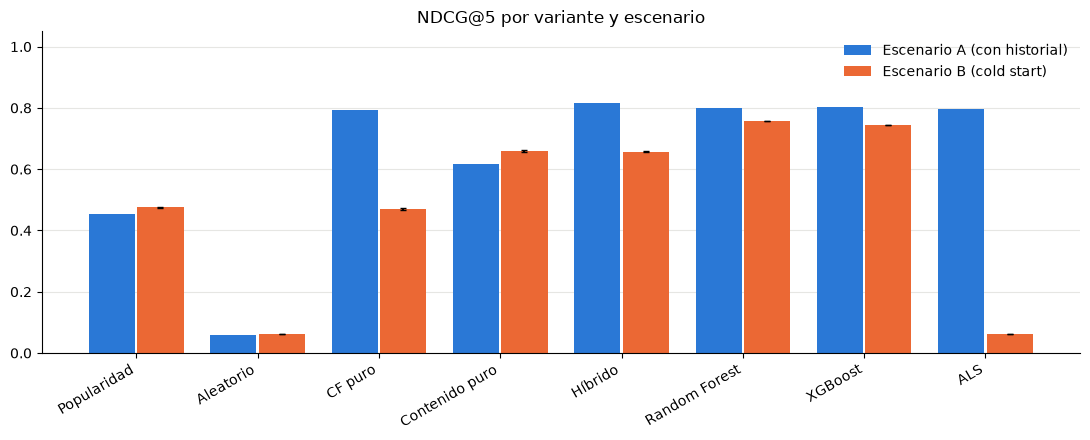

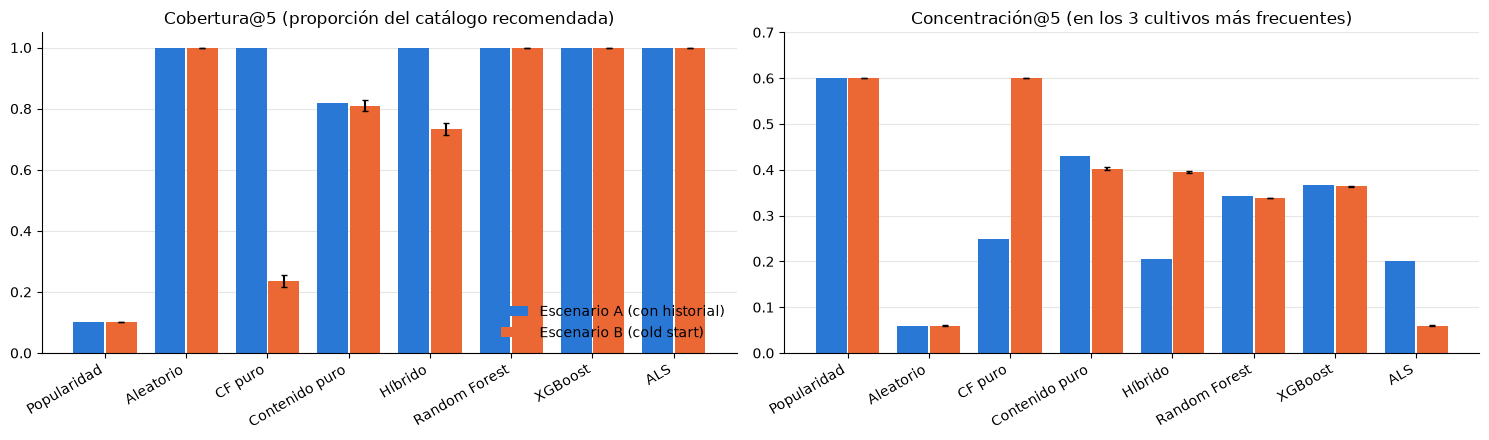

In [37]:
def barras_a_b(ax, titulo, valores_a, valores_b, err_b=None):
    x = np.arange(len(NOMBRES_MODELOS))
    ax.bar(x - 0.2, valores_a, 0.38, color=AZUL, label="Escenario A (con historial)")
    ax.bar(x + 0.2, valores_b, 0.38, yerr=err_b, capsize=2, color=NARANJA, label="Escenario B (cold start)")
    ax.set_xticks(x, NOMBRES_MODELOS, rotation=30, ha="right")
    ax.set_title(titulo)
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", color="#e6e6e3", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)


def serie(metrica):
    a = [resultados_a[n]["con_historial"][metrica] for n in NOMBRES_MODELOS]
    b = [resultados_b[n]["media"][metrica] for n in NOMBRES_MODELOS]
    e = [resultados_b[n]["std"][metrica] for n in NOMBRES_MODELOS]
    return a, b, e


fig, ax = plt.subplots(figsize=(11, 4.5))
barras_a_b(ax, "NDCG@5 por variante y escenario", *serie("ndcg@5"))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
barras_a_b(axes[0], "Cobertura@5 (proporción del catálogo recomendada)", *serie("cobertura@5"))
barras_a_b(axes[1], "Concentración@5 (en los 3 cultivos más frecuentes)", *serie("concentracion@5"))
axes[1].set_ylim(0, 0.7)
axes[0].legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

# 7. Capa económico-financiera

En esta última parte se construye la capa que traduce las recomendaciones a términos económicos y financieros. Primero se construye una ficha económica por cultivo; después, se mide el riesgo de cada cultivo; y por último, se reordenan las recomendaciones según esos criterios.

## 7.1 Ficha económica por cultivo (XCAC)

Los datos económicos proceden de la Xarxa Comptable Agrària de Catalunya (XCAC), que publica cada año, de 2015 a 2024, un fichero Excel con una columna por cultivo y una fila por partida contable (ingresos, costes directos, maquinaria, mano de obra, etc.). En la siguiente celda se descargan y se leen los diez ficheros. Como el formato cambia ligeramente de un año a otro, la fila de cabecera se localiza buscando la partida `CS000`, que es el número de explotaciones.

In [38]:
RAW_DIR_ECON = REPO_ROOT / "data" / "raw" / "capa_economica"
RAW_DIR_ECON.mkdir(parents=True, exist_ok=True)
catalogo = cultivos_base.copy()  # los 50 cultivos del recomendador, en el orden de columnas de la matriz

# La ficha se construye para todos los cultivos reales del ámbito, no solo los 50 del catálogo
catalogo_economico = ranking.rename(columns={"CPROD": "codigo_producto", "NPROD": "nombre_cultivo"})[
    ["codigo_producto", "nombre_cultivo"]].copy()
catalogo_economico["codigo_producto"] = catalogo_economico["codigo_producto"].astype(int)

XCAC_BASE = ("https://agricultura.gencat.cat/web/.content/de_departament/de02_estadistiques_observatoris/"
             "05_xarxa_comptable_agraria/arxius_estatics")
XCAC_FICHEROS = {
    2015: "Costos_XCAC_cultius_serveis_2015.xls",
    2016: "Costos_XCAC_cultius_serveis_2016.xls",
    2017: "Costos_XCAC_cultius_serveis_2017.xlsx",
    **{a: f"Resultats-compte-analitic-per-cultius-i-serveis-any-{a}.xlsx" for a in range(2018, 2025)},
}


def descargar_xcac():
    rutas = {}
    for anio, remoto in XCAC_FICHEROS.items():
        destino = RAW_DIR_ECON / f"xcac_{anio}{Path(remoto).suffix}"
        if not destino.exists():
            r = requests.get(f"{XCAC_BASE}/{remoto}", headers={"User-Agent": "Mozilla/5.0"}, timeout=120)
            r.raise_for_status()
            destino.write_bytes(r.content)
        rutas[anio] = destino
    return rutas


def parsear_xcac(path, anio):
    """Formato largo: una fila por (columna de cultivo, partida CSxxx)."""
    df = pd.read_excel(path, sheet_name=0, header=None)
    codigos_fila = df[0].astype(str).str.strip()
    fila_cabecera = df.index[codigos_fila == "CS000"][0] - 2
    columnas_cultiu = df.iloc[fila_cabecera, 3:].dropna()
    return pd.DataFrame([
        {"anio": anio, "columna_xcac": nombre, "codigo_fila": df.iat[i, 0], "valor": df.iat[i, j]}
        for i in df.index[codigos_fila.str.startswith("CS")]
        for j, nombre in columnas_cultiu.items() if pd.notna(df.iat[i, j])
    ])


def _codigo_columna(nombre):
    m = re.match(r"^([0-9A-Za-z]+)[\.\s]", str(nombre).strip())  # '123. Ordi' -> '123'
    return m.group(1) if m else str(nombre).strip()


xcac_largo = pd.concat([parsear_xcac(ruta, anio) for anio, ruta in descargar_xcac().items()], ignore_index=True)
xcac_largo["codigo_columna"] = xcac_largo["columna_xcac"].map(_codigo_columna)
xcac_pesos = (xcac_largo[xcac_largo["codigo_fila"] == "CS000"][["anio", "codigo_columna", "valor"]]
              .rename(columns={"valor": "peso"}))
print(f"{len(xcac_largo):,} valores leídos, {xcac_largo['codigo_columna'].nunique()} columnas de cultivo, "
      f"{xcac_largo['anio'].nunique()} años")

17,334 valores leídos, 50 columnas de cultivo, 10 años


**Euros constantes de 2024.** Como la serie abarca diez años, antes de comparar cifras de años distintos hay que eliminar el efecto de la inflación. Para ello, los valores monetarios se deflactan con el índice de precios de consumo general del INE (serie `IPC251852`), promediado por año, de modo que todas las cifras queden expresadas en euros de 2024. Solo se deflactan las partidas monetarias; otras, como el rendimiento en kilos o el número de explotaciones, se dejan como están.

In [39]:
IPC_SERIE = "IPC251852"
CODIGOS_MONETARIOS_XCAC = {"CS139", "CS201", "CS202", "CS401", "CS402", "CS403", "CS404"}

destino_ipc = RAW_DIR_ECON / "ipc_general_nacional_ine.json"
if not destino_ipc.exists():
    r = requests.get(f"https://servicios.ine.es/wstempus/js/ES/DATOS_SERIE/{IPC_SERIE}", params={"nult": 132},
                     headers={"User-Agent": "Mozilla/5.0"}, timeout=60)
    r.raise_for_status()
    destino_ipc.write_bytes(r.content)
ipc_json = json.loads(destino_ipc.read_text())
assert ipc_json["COD"] == IPC_SERIE
ipc_anual = (pd.DataFrame(ipc_json["Data"]).rename(columns={"Anyo": "anio", "Valor": "ipc"})
             .query("2015 <= anio <= 2024").groupby("anio")["ipc"].mean())
deflactor = ipc_anual[2024] / ipc_anual

es_monetario = xcac_largo["codigo_fila"].isin(CODIGOS_MONETARIOS_XCAC)
xcac_largo["valor_nominal"] = xcac_largo["valor"]
xcac_largo["valor"] = np.where(es_monetario, xcac_largo["valor_nominal"] * xcac_largo["anio"].map(deflactor),
                               xcac_largo["valor_nominal"])
print(pd.DataFrame({"IPC": ipc_anual.round(3), "deflactor": deflactor.round(4)}).T.to_string())
print(f"\n{es_monetario.sum():,}/{len(xcac_largo):,} valores monetarios deflactados")

anio          2015     2016     2017     2018     2019    2020      2021     2022      2023     2024
IPC        93.4120  93.2220  95.0460  96.6380  97.3140  97.000  100.0000  108.391  112.2190  115.333
deflactor   1.2347   1.2372   1.2134   1.1935   1.1852   1.189    1.1533    1.064    1.0277    1.000

3,143/17,334 valores monetarios deflactados


**Correspondencia entre el catálogo y las columnas de XCAC.** A continuación se indica a qué columna de XCAC corresponde cada cultivo del catálogo. Esta correspondencia se ha revisado a mano, comprobando las columnas reales de los diez años, y puede ser de tres tipos:

- **Directa**: el cultivo tiene su propia columna.
- **Agrupada**: la fuente reúne varios cultivos en una sola columna, por lo que comparten la misma ficha. Se marca con `es_aproximacion=True`.
- **Viña**: la fuente distingue once variedades, que se combinan en una media ponderada por el número de explotaciones.

Los cultivos que comparten columna forman un **grupo de equivalencia**, y sus fichas son iguales por construcción.

In [40]:
# codigo_producto -> (columnas de XCAC, es_aproximacion, nota)
CROSSWALK_XCAC = {
    1:   (["120"], False, None),                                              # BLAT TOU
    2:   (["120"], True, "combinado con Blat tou en la fuente"),              # ESPELTA
    4:   (["126"], False, None),                                              # BLAT DE MORO
    5:   (["123"], False, None),                                              # ORDI
    6:   (["128"], True, "'Altres cereals per gra'"),                         # SÈGOL
    7:   (["128"], True, "'Altres cereals per gra'"),                         # SORGO
    8:   (["124"], False, None),                                              # CIVADA
    10:  (["128"], True, "'Altres cereals per gra'"),                         # MILL
    13:  (["128"], True, "'Altres cereals per gra'"),                         # TRITICALE
    33:  (["332"], False, None),                                              # GIRA-SOL
    35:  (["331"], False, None),                                              # COLZA
    40:  (["360"], True, "combinado con Fava y Favó en la fuente"),           # PÈSOL
    41:  (["360"], True, "combinado con Pèsol y Favó en la fuente"),          # FAVA
    390: (["360"], True, "combinado con Pèsol y Fava en la fuente"),          # FAVÓ
    52:  (["360"], True, "leguminosa grano (clasificación MAPA)"),           # VEÇA
    60:  (["10922"], True, "leguminosa forrajera (Eurostat G2100)"),          # ALFALS
    67:  (["10922"], True, "'Lleguminoses farratgeres'"),                     # TREPADELLA
    68:  (["10923"], True, "'Altres farratgeres'"),                           # FESTUCA
    69:  (["10923"], True, "'Altres farratgeres'"),                           # RAIGRÀS PERENNE
    78:  (["10923"], True, "'Altres farratgeres'"),                           # RAIGRÀS MULTIFLORUM
    80:  (["127"], False, None),                                              # ARRÒS
    101: (["282"], False, None),                                              # OLIVERA
    102: (["2860", "2861", "2862", "2863", "2864", "2865", "2866", "2867", "2868", "2869", "286A", "286B"], False,
          "media de variedades ponderada por nº de explotaciones"),           # VINYA
    104: (["3513"], False, None),                                             # AMETLLER
    105: (["3504"], False, None),                                             # PRESSEGUER
    106: (["3504"], True, "combinado con Presseguer en la fuente"),           # NECTARINER
    107: (["3503"], False, None),                                             # ALBERCOQUER
    108: (["3493"], False, None),                                             # PERERA
    109: (["3491"], False, None),                                             # POMERA
    110: (["3501"], False, None),                                             # CIRERER
    112: (["3515"], True, "'Altra fruita seca'"),                             # NOGUERA
    122: (["3302"], False, None),                                             # GARROFER
    123: (["3512"], False, None),                                             # AVELLANER
    124: (["3515"], True, "'Altra fruita seca'"),                             # PISTATXER O FESTUC
    157: (["3394"], True, "'Cebes' (no incluye calçot)"),                     # CEBA I CALÇOT
    164: (["3381"], False, "solo 2024 con dato"),                             # CARXOFA
    193: (["10790"], True, "'Altres hortalisses'"),                           # HORTA
    202: (["3505"], True, "'Altra fruita de pinyol'"),                        # PRÉSSEC PLA
    204: (["355"], True, "combinado con Mandariner en la fuente"),            # CLEMENTINA
    206: (["354"], False, None),                                              # TARONGER
    210: (["355"], True, "combinado con Clementina en la fuente"),            # MANDARINER HÍBRID
    # Cultivos del ámbito fuera del catálogo de 50
    99:  (["130"], False, None),                                              # PATATA
    160: (["335"], False, "combinado con Bròcoli en la fuente"),              # COL-I-FLOR
    154: (["335"], False, "combinado con Coliflor en la fuente"),             # BRÒCOLI
    197: (["337"], False, None),                                              # TOMÀQUET
    153: (["3412"], False, "solo un año con dato"),                           # MELÓ
    167: (["3394"], True, "'Cebes'"),                                         # CEBA TENDRA
    201: (["3504"], True, "combinado con Presseguer/Nectariner en la fuente"),  # NECTARINA PLANA
    932: (["344"], False, None),                                              # PLANTA ORNAMENTAL
    91:  (["344"], False, "combinado con Planta ornamental en la fuente"),    # FLOR TALLADA
}
CODIGOS_RENDIMIENTO_NO_KG = {932, 91}  # XCAC mide la floricultura en otra unidad

# Grupos de equivalencia: misma tupla de columnas de XCAC
_grupos = {}
for codigo, (columnas, _, _) in CROSSWALK_XCAC.items():
    _grupos.setdefault(tuple(sorted(columnas)), []).append(codigo)
grupo_xcac = pd.DataFrame([{"codigo_producto": c, "grupo_xcac_id": g}
                           for g, (_, miembros) in enumerate(sorted(_grupos.items()), start=1) for c in miembros])

en_catalogo = [c for c in CROSSWALK_XCAC if c in set(catalogo["codigo_producto"])]
print(f"{len(CROSSWALK_XCAC)} cultivos del ámbito con columna en XCAC; {len(en_catalogo)} de ellos en el catálogo de "
      f"{len(catalogo)}, agrupados en {grupo_xcac[grupo_xcac['codigo_producto'].isin(en_catalogo)]['grupo_xcac_id'].nunique()} grupos")

50 cultivos del ámbito con columna en XCAC; 41 de ellos en el catálogo de 50, agrupados en 28 grupos


**Ensamblado de la ficha y cálculo del margen.** En esta celda se construye la ficha económica de cada cultivo. Cada partida se agrega en los diez años con una media ponderada por el número de explotaciones de cada año, de modo que un año con muchas explotaciones en la muestra pesa más que uno con pocas. El producto bruto es la suma del producto principal y el subproducto, sin incluir las subvenciones. El margen (ecuación 4.1 de la memoria) se calcula restando al producto bruto los costes directos, la maquinaria propia y contratada y la mano de obra asalariada, y solo se calcula cuando están disponibles todas esas partidas:

$$m_c = b_c - d_c - k^{p}_c - k^{c}_c - w_c$$

In [41]:
def xcac_valor(columnas, codigo_fila, anio=None):
    sub = xcac_largo[xcac_largo["codigo_columna"].isin(columnas) & (xcac_largo["codigo_fila"] == codigo_fila)]
    if anio is not None:
        sub = sub[sub["anio"] == anio]
    sub = sub.merge(xcac_pesos, on=["anio", "codigo_columna"], how="left").dropna(subset=["peso"])
    if sub.empty or sub["peso"].sum() == 0:
        return np.nan
    return (sub["valor"] * sub["peso"]).sum() / sub["peso"].sum()


def componentes(columnas, anio=None):
    """Partidas de la ficha. Agregadas en los diez años (anio=None) se redondean a un decimal por partida."""
    def v(fila):
        x = xcac_valor(columnas, fila, anio)
        return round(x, 1) if anio is None and pd.notna(x) else x

    principal, sub = v("CS201"), v("CS202")
    return {
        "rendimiento_medio_kg_ha": v("CS001"),
        "producto_bruto_ha": np.nan if pd.isna(principal) else principal + np.nan_to_num(sub),
        "costes_directos_ha": v("CS139"),
        "coste_maquinaria_propia_ha": v("CS403"),
        "coste_maquinaria_contratada_ha": v("CS404"),
        "coste_mano_obra_asalariada_ha": np.nan_to_num(v("CS401")) + np.nan_to_num(v("CS402")),
    }


COMPONENTES_COSTE = ["costes_directos_ha", "coste_maquinaria_propia_ha",
                     "coste_maquinaria_contratada_ha", "coste_mano_obra_asalariada_ha"]

ficha_xcac = pd.DataFrame([{"codigo_producto": c, "es_aproximacion_xcac": aprox, "nota_xcac": nota,
                            **{k: round(v, 1) for k, v in componentes(cols).items()}}
                           for c, (cols, aprox, nota) in CROSSWALK_XCAC.items()])
ficha_xcac.loc[ficha_xcac["codigo_producto"].isin(CODIGOS_RENDIMIENTO_NO_KG), "rendimiento_medio_kg_ha"] = np.nan

tiene_costes = ficha_xcac[COMPONENTES_COSTE].notna().all(axis=1)
tiene_ingreso = ficha_xcac["producto_bruto_ha"].notna()
ficha_xcac["costes_totales_ha"] = np.where(tiene_costes, ficha_xcac[COMPONENTES_COSTE].sum(axis=1).round(1), np.nan)
ficha_xcac["margen_bruto_ha"] = np.where(tiene_costes & tiene_ingreso,
                                         (ficha_xcac["producto_bruto_ha"] - ficha_xcac["costes_totales_ha"]).round(1), np.nan)
ficha_xcac["nivel_dato_economico"] = np.select([tiene_costes & tiene_ingreso, tiene_ingreso],
                                               ["margen_completo", "solo_ingreso_bruto"], default="sin_dato")
print(ficha_xcac["nivel_dato_economico"].value_counts().to_string())

nivel_dato_economico
margen_completo    50


**Respaldo de rendimiento.** Algunos cultivos del ámbito no tienen columna en XCAC. Para ellos, se toma al menos el rendimiento físico (en kilos por hectárea) de la serie comarcal de superficies y rendimientos de la Generalitat. Como no se dispone de un precio fiable para ellos, quedan marcados como `sin_dato` a efectos económicos, y no se les imputa ninguna cifra.

In [42]:
URLS_RENDIMIENTO = {
    "herbacis": "https://analisi.transparenciacatalunya.cat/resource/3kit-yica.json?$limit=50000",
    "llenyosos": "https://analisi.transparenciacatalunya.cat/resource/u3g3-hp52.json?$limit=50000",
}
COLUMNAS_RENDIMIENTO = {  # (superficie, rendimiento) en secano y en regadío
    "herbacis": [("superf_cie_en_sec_total_ha", "rendiment_en_sec_kg_ha"),
                 ("superf_cie_en_regadiu_total", "rendiment_en_regadiu_kg_ha")],
    "llenyosos": [("superf_cie_productiva_en", "rendiment_en_sec_kg_ha"),
                  ("superf_cie_productiva_en_1", "rendiment_en_regadiu_kg_ha")],
}
# Nombres que no coinciden literalmente con el de la declaración (revisados a mano)
EQUIVALENCIAS_RENDIMIENTO = {
    241: ("Associació Veça - Civada farratgeres", "herbacis"), 242: ("Associació veça i triticale farratgeres", "herbacis"),
    243: ("Associació veça i blat farratgeres", "herbacis"), 244: ("Associació veça i ordi farratgeres", "herbacis"),
    299: ("Associació pèsol i civada farratgeres", "herbacis"), 298: ("Associació pèsol i ordi farratgeres", "herbacis"),
    185: ("Carbassa", "herbacis"), 49: ("Mongeta seca", "herbacis"), 53: ("Erbs", "herbacis"),
    179: ("Nap i altres", "herbacis"), 82: ("Remolatxa de taula", "herbacis"), 117: ("Castanya (fruit)", "llenyosos"),
    111: ("Pruner", "llenyosos"), 219: ("Maduixa i maduixot", "herbacis"), 938: ("Maduixa i maduixot", "herbacis"),
}


def _norm(s):
    s = str(s).strip().upper().replace("·", "").replace("-", " ")
    return "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")


tablas_rendimiento = {}
for nombre, url in URLS_RENDIMIENTO.items():
    destino = RAW_DIR_ECON / f"rendiments_{nombre}_catalunya.json"
    if not destino.exists():
        r = requests.get(url, timeout=180)
        r.raise_for_status()
        destino.write_bytes(r.content)
    df = pd.read_json(destino)
    for col in ["any"] + [c for par in COLUMNAS_RENDIMIENTO[nombre] for c in par]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    tablas_rendimiento[nombre] = df
nombres_por_tabla = {t: {_norm(c): c for c in df["cultiu"].unique()} for t, df in tablas_rendimiento.items()}


def rendimiento_respaldo(codigo, nombre_cultivo):
    cultiu, tabla = EQUIVALENCIAS_RENDIMIENTO.get(codigo, (None, None))
    if cultiu is None:
        tabla = next((t for t, mapa in nombres_por_tabla.items() if _norm(nombre_cultivo) in mapa), None)
        cultiu = nombres_por_tabla[tabla][_norm(nombre_cultivo)] if tabla else None
    if cultiu is None:
        return np.nan
    sub = tablas_rendimiento[tabla][tablas_rendimiento[tabla]["cultiu"] == cultiu]
    valores, pesos = [], []
    for col_sup, col_rend in COLUMNAS_RENDIMIENTO[tabla]:
        v = sub[(sub[col_sup] > 0) & (sub[col_rend] > 0)]
        valores += v[col_rend].tolist()
        pesos += v[col_sup].tolist()
    return round(np.average(valores, weights=pesos), 1) if sum(pesos) > 0 else np.nan


sin_xcac = catalogo_economico[~catalogo_economico["codigo_producto"].isin(CROSSWALK_XCAC)]
ficha_respaldo = pd.DataFrame({
    "codigo_producto": sin_xcac["codigo_producto"].to_numpy(),
    "rendimiento_medio_kg_ha": [rendimiento_respaldo(c, n) for c, n in zip(sin_xcac["codigo_producto"], sin_xcac["nombre_cultivo"])],
    "nivel_dato_economico": "sin_dato",
    "nota_xcac": "sin columna en XCAC -- rendimiento de respaldo (Generalitat, comarcal)",
})

ficha_economica = (catalogo_economico.merge(pd.concat([ficha_xcac, ficha_respaldo], ignore_index=True),
                                            on="codigo_producto", how="left")
                   .merge(grupo_xcac, on="codigo_producto", how="left"))
ficha_economica["nivel_dato_economico"] = ficha_economica["nivel_dato_economico"].fillna("sin_dato")

ficha_catalogo = ficha_economica[ficha_economica["codigo_producto"].isin(catalogo["codigo_producto"])]
completos = ficha_catalogo["nivel_dato_economico"] == "margen_completo"
print(f"Cultivos del ámbito con margen completo: {(ficha_economica['nivel_dato_economico'] == 'margen_completo').sum()}")
print(f"Del catálogo del recomendador con ficha completa: {completos.sum()} de {len(ficha_catalogo)}")
print("Sin ficha:", ", ".join(ficha_catalogo.loc[~completos, "nombre_cultivo"]))

Cultivos del ámbito con margen completo: 50
Del catálogo del recomendador con ficha completa: 41 de 50
Sin ficha: VIVER - PRODUCTOR MVR, FIGUERA, VEÇA I CIVADA, VEÇA I TRITICALE, VEÇA I BLAT, VEÇA I ORDI, BARREJA FARRATGERES, TÒFONA, VEÇA I RAIGRÀS


## 7.2 Margen anual y riesgo por cultivo

Para medir el riesgo es necesario ver cómo varía el margen de un año a otro. Por eso, en la siguiente celda se recalcula el margen año a año, con las mismas partidas que la ficha. Si un año no trae todas las partidas de un cultivo, ese año queda fuera para ese cultivo, sin rellenarlo.

In [43]:
filas = []
for codigo in en_catalogo:
    columnas = CROSSWALK_XCAC[codigo][0]
    for anio in sorted(xcac_largo["anio"].unique()):
        c = componentes(columnas, anio)
        costes = [c["costes_directos_ha"], c["coste_maquinaria_propia_ha"], c["coste_maquinaria_contratada_ha"]]
        if pd.isna(c["producto_bruto_ha"]) or any(pd.isna(x) for x in costes):
            continue
        filas.append({"codigo_producto": codigo, "anio": anio,
                      "margen_bruto_ha": c["producto_bruto_ha"] - sum(costes) - c["coste_mano_obra_asalariada_ha"],
                      "peso_explotaciones": xcac_pesos.loc[xcac_pesos["codigo_columna"].isin(columnas)
                                                           & (xcac_pesos["anio"] == anio), "peso"].sum()})
margen_anual = pd.DataFrame(filas)
print(f"{len(margen_anual)} pares (cultivo, año) con margen válido, "
      f"de un máximo de {len(en_catalogo) * xcac_largo['anio'].nunique()}")

# Nombre de cada grupo de equivalencia, con los cultivos del catálogo que lo forman
nombre_grupo = (catalogo.merge(grupo_xcac, on="codigo_producto").groupby("grupo_xcac_id")["nombre_cultivo"]
                .agg(lambda s: " / ".join(n.capitalize() for n in sorted(s))))

379 pares (cultivo, año) con margen válido, de un máximo de 410


**Tabla de la ficha económica** (tabla 4.5 de la memoria). En esta celda se muestra la ficha económica de los cultivos del catálogo que tienen todos los datos, en euros constantes de 2024 por hectárea. Hay una fila por grupo de equivalencia, ya que los cultivos que comparten columna en XCAC comparten también la ficha. La última columna indica cuántos de los diez años tienen dato completo.

In [44]:
# Ficha económica del catálogo (tabla 4.5): una fila por grupo de equivalencia
anios_margen = margen_anual.groupby("codigo_producto").size().rename("años")
tabla_ficha = (ficha_catalogo[completos]
               .assign(maquinaria=lambda d: d["coste_maquinaria_propia_ha"] + d["coste_maquinaria_contratada_ha"])
               .merge(anios_margen, left_on="codigo_producto", right_index=True, how="left")
               .drop_duplicates("grupo_xcac_id"))
tabla_ficha["cultivo"] = tabla_ficha["grupo_xcac_id"].map(nombre_grupo)
tabla_ficha = tabla_ficha.set_index("cultivo")[
    ["rendimiento_medio_kg_ha", "producto_bruto_ha", "costes_directos_ha", "maquinaria",
     "coste_mano_obra_asalariada_ha", "margen_bruto_ha", "años"]].sort_values("producto_bruto_ha", ascending=False)
print(f"Ficha económica (€ constantes de 2024 por ha): {len(tabla_ficha)} filas para {completos.sum()} cultivos")
tabla_ficha.round(1)

Ficha económica (€ constantes de 2024 por ha): 28 filas para 41 cultivos


,rendimiento_medio_kg_ha,producto_bruto_ha,costes_directos_ha,maquinaria,coste_mano_obra_asalariada_ha,margen_bruto_ha,años
cultivo,,,,,,,
Ceba i calçot,22404.9,15952.9,6046.4,2279.1,4131.6,3495.8,10
Carxofa,11961.2,15373.4,5631.4,1210.0,5126.2,3405.8,1
Horta,14835.7,15282.0,6758.3,1514.5,4740.5,2268.7,10
Pomera,35625.5,14366.8,6105.2,1446.5,4567.8,2247.3,10
Cirerer,5614.0,14088.6,6245.0,824.0,4736.5,2283.1,8
Nectariner / Presseguer,23494.4,11875.5,5085.8,1316.1,3410.7,2062.9,10
Préssec pla,21528.9,11607.4,5374.3,801.9,3314.4,2116.8,10
Albercoquer,9632.9,10965.2,3540.2,760.9,1781.9,4882.2,10
Perera,19810.9,9534.0,4616.5,933.6,2507.0,1476.9,10


**Medidas de riesgo** (sección 4.3.2 de la memoria). A partir de la serie de márgenes anuales, se calculan las siguientes medidas para cada cultivo, con la media y la desviación típica ponderadas por el número de explotaciones:

- **Razón riesgo-retorno** ($\mu/\sigma$): margen esperado dividido por su desviación típica. Cuanto mayor, más margen se obtiene por cada unidad de variabilidad.
- **Escenario de estrés** ($\mu-\sigma$): margen esperado menos una desviación típica, como aproximación sencilla a un año malo.
- **Cociente de Sortino**: como la razón riesgo-retorno, pero solo tiene en cuenta la variabilidad a la baja, ya que la variabilidad al alza no supone un riesgo.
- **Déficit esperado al 20 %**: media de los años que caen en el peor 20 % de la serie (como mínimo, un año).
- **Peor año**: el margen más bajo observado en la serie.

Un cultivo con un solo año de dato no permite calcular una desviación típica, así que queda sin dato de riesgo.

In [45]:
MEDIDAS_RIESGO = ["margen_esperado_ha", "desviacion_margen_ha", "margen_estres_ha", "ratio_riesgo_retorno",
                  "ratio_sortino", "deficit_esperado_20_ha", "peor_anio_ha"]


def medidas_riesgo(g):
    if len(g) < 2 or g["peso_explotaciones"].sum() == 0:
        return pd.Series(np.nan, index=MEDIDAS_RIESGO)
    w, m = g["peso_explotaciones"], g["margen_bruto_ha"]
    media = np.average(m, weights=w)
    sigma = np.sqrt(np.average((m - media) ** 2, weights=w))
    semi = np.sqrt(np.average(np.minimum(0, m - media) ** 2, weights=w))
    return pd.Series({
        "margen_esperado_ha": round(media, 1), "desviacion_margen_ha": round(sigma, 1),
        "margen_estres_ha": round(round(media, 1) - round(sigma, 1), 1),
        "ratio_riesgo_retorno": round(round(media, 1) / round(sigma, 1), 2),
        "ratio_sortino": round(round(media, 1) / round(semi, 1), 2),
        "deficit_esperado_20_ha": round(m.nsmallest(max(1, round(0.2 * len(g)))).mean(), 1),
        "peor_anio_ha": round(m.min(), 1),
    })


riesgo_cultivo = (margen_anual.groupby("codigo_producto").apply(medidas_riesgo, include_groups=False).reset_index()
                  .merge(anios_margen, left_on="codigo_producto", right_index=True)
                  .merge(catalogo, on="codigo_producto").merge(grupo_xcac, on="codigo_producto"))

# Tabla 4.6: una fila por grupo de equivalencia (su serie de márgenes es la misma)
riesgo_grupo = riesgo_cultivo.drop_duplicates("grupo_xcac_id").copy()
riesgo_grupo["cultivo"] = riesgo_grupo["grupo_xcac_id"].map(nombre_grupo)
riesgo_grupo = riesgo_grupo.set_index("cultivo")[
    ["margen_esperado_ha", "desviacion_margen_ha", "margen_estres_ha", "ratio_riesgo_retorno", "ratio_sortino",
     "deficit_esperado_20_ha", "peor_anio_ha", "años"]].sort_values("ratio_riesgo_retorno", ascending=False)
riesgo_grupo

,margen_esperado_ha,desviacion_margen_ha,margen_estres_ha,ratio_riesgo_retorno,ratio_sortino,deficit_esperado_20_ha,peor_anio_ha,años
cultivo,,,,,,,,
Alfals / Trepadella,431.4,124.7,306.7,3.46,4.37,244.8,211.9,10
Olivera,478.9,149.7,329.2,3.20,5.21,319.7,310.8,10
Blat de moro,846.5,291.4,555.1,2.90,4.92,451.8,395.7,10
Vinya,1143.4,408.1,735.3,2.80,3.26,454.9,9.7,10
Clementina / Mandariner híbrid,2491.4,1134.9,1356.5,2.20,4.01,1010.3,670.1,10
Festuca / Raigràs multiflorum / Raigràs perenne,277.5,128.1,149.4,2.17,2.81,85.6,52.0,10
Garrofer,1077.0,498.7,578.3,2.16,3.41,523.8,523.8,4
Ordi,243.2,122.2,121.0,1.99,2.54,57.1,25.5,10
Horta,2268.7,1187.4,1081.3,1.91,2.61,294.5,137.2,10


**Resumen de las medidas de riesgo.** En esta celda se calculan algunos recuentos sobre la tabla de riesgo, como cuántos cultivos quedan con margen negativo en el escenario de estrés o cuántos cambian de puesto al ordenar por el cociente de Sortino en lugar de por la razón riesgo-retorno. También se representa la razón riesgo-retorno de todos los cultivos en un gráfico de barras.

Grupos con dato de riesgo: 27
  pasan a margen negativo bajo estrés: 6
  Sortino mayor que la razón riesgo-retorno: 25
  cambian de puesto al ordenar por Sortino: 18
  margen positivo bajo estrés pero con alguna campaña en pérdidas: 7


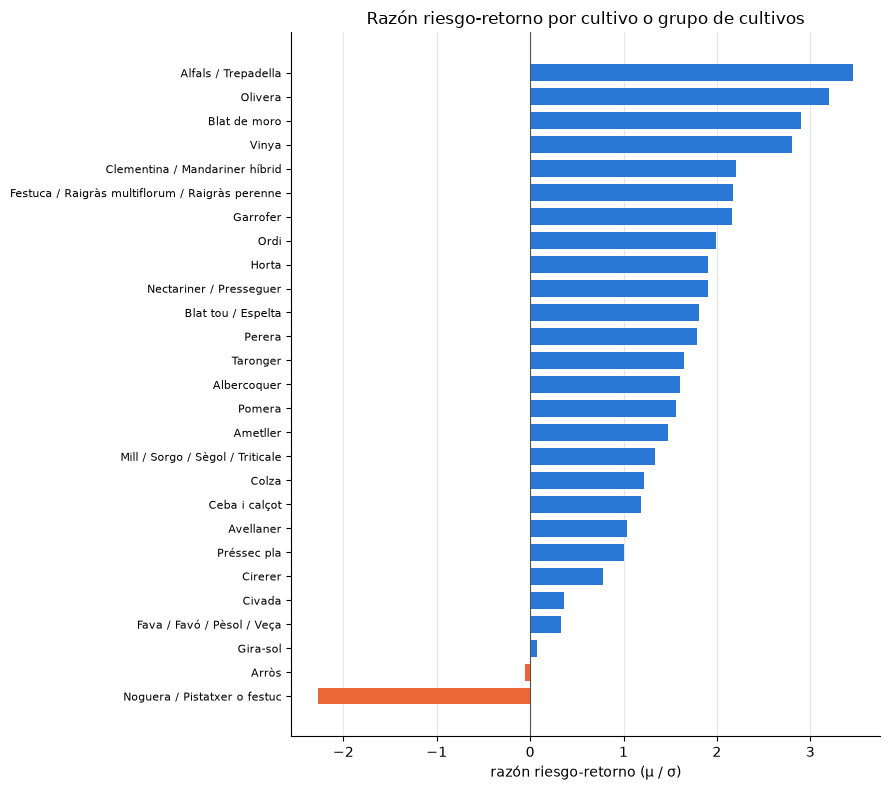

In [46]:
g = riesgo_grupo.dropna(subset=["ratio_riesgo_retorno"])
cambia_puesto = (g["ratio_riesgo_retorno"].rank(ascending=False, method="min")
                 != g["ratio_sortino"].rank(ascending=False, method="min")).sum()
print(f"Grupos con dato de riesgo: {len(g)}")
print(f"  pasan a margen negativo bajo estrés: {(g['margen_estres_ha'] < 0).sum()}")
print(f"  Sortino mayor que la razón riesgo-retorno: {(g['ratio_sortino'] > g['ratio_riesgo_retorno']).sum()}")
print(f"  cambian de puesto al ordenar por Sortino: {cambia_puesto}")
print(f"  margen positivo bajo estrés pero con alguna campaña en pérdidas: "
      f"{((g['margen_estres_ha'] > 0) & (g['peor_anio_ha'] < 0)).sum()}")

fig, ax = plt.subplots(figsize=(9, 8))
g_orden = g.sort_values("ratio_riesgo_retorno")
colores = [NARANJA if v < 0 else AZUL for v in g_orden["ratio_riesgo_retorno"]]
ax.barh(g_orden.index, g_orden["ratio_riesgo_retorno"], color=colores, height=0.7)
ax.axvline(0, color="#52514e", linewidth=0.8)
ax.set_xlabel("razón riesgo-retorno (μ / σ)")
ax.set_title("Razón riesgo-retorno por cultivo o grupo de cultivos")
ax.tick_params(axis="y", labelsize=8)
ax.grid(axis="x", color="#e6e6e3", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 7.3 Reordenación del *top-k*

En este apartado se unen las dos capas del sistema. La función `recalcular_topk` recibe la lista de cultivos recomendados a una parcela (su *top-k*) y le añade la ficha económica de cada cultivo. El cruce se hace por código de cultivo, sin distinguir secano de regadío, ya que XCAC no hace esa distinción.

El usuario puede ajustar dos supuestos que cambian el coste de cada cultivo: declarar que toda la maquinaria es propia (en cuyo caso se descuenta la contratada) o que la mano de obra es familiar (en cuyo caso su coste pasa a ser cero). Además, si se le pasa la tabla de riesgo, la función calcula la relación entre el ingreso y el coste de campaña, tanto en el escenario esperado como en el de estrés, y marca si el cultivo cubre el coste más un interés de financiación del 5 %. Este tipo es solo ilustrativo y no corresponde a ningún producto financiero real.

In [47]:
COSTE_FINANCIACION = 0.05  # tipo ilustrativo, no el de ningún producto real


def recalcular_topk(top_k, riesgo=None, toda_maquinaria_propia=False, mano_obra_familiar=False,
                    coste_financiacion=COSTE_FINANCIACION):
    df = top_k.merge(ficha_economica.drop(columns="nombre_cultivo"), left_on="cultivo", right_on="codigo_producto", how="left")
    completo = df["nivel_dato_economico"] == "margen_completo"
    maquinaria = df["coste_maquinaria_propia_ha"] + (0 if toda_maquinaria_propia else df["coste_maquinaria_contratada_ha"])
    mano_obra = 0 if mano_obra_familiar else df["coste_mano_obra_asalariada_ha"]
    df["coste_estimado_ha"] = np.where(completo, (df["costes_directos_ha"] + maquinaria + mano_obra).round(1), np.nan)
    df["margen_estimado_ha"] = np.where(completo, (df["producto_bruto_ha"] - df["coste_estimado_ha"]).round(1), np.nan)
    salida = ["rank", "nombre_cultivo", "producto_bruto_ha", "coste_estimado_ha", "margen_estimado_ha"]

    if riesgo is not None:
        df = df.merge(riesgo[["codigo_producto", "margen_esperado_ha", "margen_estres_ha"]], on="codigo_producto", how="left")
        for escenario, col in [("esperado", "margen_esperado_ha"), ("estres", "margen_estres_ha")]:
            ratio = (df[col] + df["costes_totales_ha"]) / df["costes_totales_ha"]
            df[f"ingreso_coste_{escenario}"] = ratio.round(3)
            df[f"cubre_financiacion_{escenario}"] = ratio >= 1 + coste_financiacion
        salida += ["ingreso_coste_esperado", "ingreso_coste_estres", "cubre_financiacion_esperado", "cubre_financiacion_estres"]
    return df[salida]

**Modelo que genera las recomendaciones.** Para esta capa ya no hace falta separar entrenamiento y test, porque no se está evaluando el modelo, sino utilizándolo. Por eso, el modelo Híbrido de LightFM se entrena con las 200.000 parcelas, con los hiperparámetros elegidos en el escenario B. Como se ha explicado al principio del cuaderno, se entrena con un solo hilo para que el resultado sea siempre el mismo.

In [48]:
def entrenar_hibrido_produccion(hp):
    feat_disperso, _, _ = preparar_features(parcelas_features)
    feat_hibrido = sp.hstack([identidad_parcelas, feat_disperso], format="csr")
    coo = matriz_confianza.tocoo()
    binaria = sp.coo_matrix((np.ones_like(coo.data, dtype=np.float32), (coo.row, coo.col)), shape=coo.shape)
    pesos = sp.coo_matrix((coo.data.astype(np.float32), (coo.row, coo.col)), shape=coo.shape)
    modelo = LightFM(**hp, loss="warp", random_state=SEED)
    modelo.fit(binaria, user_features=feat_hibrido, item_features=identidad_items,
               sample_weight=pesos, epochs=15, num_threads=1, verbose=False)
    return scores_lightfm(modelo, feat_hibrido, identidad_items)


print(f"Híbrido de producción: {hp_b['Híbrido']}")
scores_produccion = entrenar_hibrido_produccion(hp_b["Híbrido"])


def top_k_hibrido(parcela_id, k=10):
    fila = scores_produccion[idx_parcela[parcela_id]]
    orden = np.argsort(-fila)[:k]
    return pd.DataFrame({"parcela_id": parcela_id, "cultivo": cultivo_codigos[orden], "rank": range(1, k + 1),
                         "score": fila[orden], "nombre_cultivo": catalogo["nombre_cultivo"].to_numpy()[orden]})

Híbrido de producción: {'no_components': 50, 'learning_rate': 0.01}


**Parcela de ejemplo** (tabla 4.7 y sección 4.4.2 de la memoria). En la siguiente celda se obtiene el *top-10* de una parcela concreta y se calcula su ficha económica con dos supuestos distintos: primero, con la mezcla observada de maquinaria propia y contratada y la mano de obra asalariada; y después, suponiendo que toda la maquinaria es propia y que la mano de obra es familiar.

In [49]:
parcela_ejemplo = "08001:0:0:10:12:1"
top_k_ejemplo = top_k_hibrido(parcela_ejemplo)

print("Supuestos por defecto (maquinaria mixta observada, mano de obra asalariada):")
display(recalcular_topk(top_k_ejemplo))
print("Toda la maquinaria propia y mano de obra familiar:")
display(recalcular_topk(top_k_ejemplo, toda_maquinaria_propia=True, mano_obra_familiar=True))

Supuestos por defecto (maquinaria mixta observada, mano de obra asalariada):


,rank,nombre_cultivo,producto_bruto_ha,coste_estimado_ha,margen_estimado_ha
0,1,VINYA,3549.1,2405.8,1143.3
1,2,ORDI,855.4,612.2,243.2
2,3,HORTA,15282.0,13013.3,2268.7
3,4,BLAT TOU,1008.1,702.4,305.7
4,5,ALFALS,1200.2,768.8,431.4
5,6,CIVADA,572.5,521.3,51.2
6,7,OLIVERA,1466.3,987.3,479.0
7,8,AVELLANER,1289.3,866.4,422.9
8,9,RAIGRÀS MULTIFLORUM,921.9,644.5,277.4
9,10,POMERA,14366.8,12119.5,2247.3


Toda la maquinaria propia y mano de obra familiar:


,rank,nombre_cultivo,producto_bruto_ha,coste_estimado_ha,margen_estimado_ha
0,1,VINYA,3549.1,1358.8,2190.3
1,2,ORDI,855.4,518.1,337.3
2,3,HORTA,15282.0,8119.4,7162.6
3,4,BLAT TOU,1008.1,592.8,415.3
4,5,ALFALS,1200.2,623.9,576.3
5,6,CIVADA,572.5,442.5,130.0
6,7,OLIVERA,1466.3,731.3,735.0
7,8,AVELLANER,1289.3,576.3,713.0
8,9,RAIGRÀS MULTIFLORUM,921.9,524.7,397.2
9,10,POMERA,14366.8,7240.9,7125.9


**Las cuatro ordenaciones.** Un mismo *top-10* se puede ordenar de cuatro maneras distintas: según el modelo, por margen esperado, por razón riesgo-retorno y por margen en el escenario de estrés. En esta celda se muestran las cuatro ordenaciones de la parcela de ejemplo una junto a otra, con el valor del criterio correspondiente entre paréntesis.

In [50]:
# El mismo top-10 ordenado por los cuatro criterios (tabla 4.7)
t = top_k_ejemplo.merge(riesgo_cultivo[["codigo_producto", "margen_esperado_ha", "ratio_riesgo_retorno", "margen_estres_ha"]],
                        left_on="cultivo", right_on="codigo_producto", how="left")


def ordenar(col):
    s = t.dropna(subset=[col]).sort_values(col, ascending=False)
    return [f"{n.capitalize()} ({v:,.2f})" if col == "ratio_riesgo_retorno" else f"{n.capitalize()} ({v:,.1f})"
            for n, v in zip(s["nombre_cultivo"], s[col])]


ordenes = {"Orden del modelo": [n.capitalize() for n in t["nombre_cultivo"]],
           "Por margen esperado": ordenar("margen_esperado_ha"),
           "Por razón riesgo-retorno": ordenar("ratio_riesgo_retorno"),
           "Por margen en estrés": ordenar("margen_estres_ha")}
pd.DataFrame({k: pd.Series(v, index=range(1, len(v) + 1)) for k, v in ordenes.items()}).fillna("---")

,Orden del modelo,Por margen esperado,Por razón riesgo-retorno,Por margen en estrés
1,Vinya,"Horta (2,268.7)",Alfals (3.46),"Horta (1,081.3)"
2,Ordi,"Pomera (2,247.4)",Olivera (3.20),Pomera (804.9)
3,Horta,"Vinya (1,143.4)",Vinya (2.80),Vinya (735.3)
4,Blat tou,Olivera (478.9),Raigràs multiflorum (2.17),Olivera (329.2)
5,Alfals,Alfals (431.4),Ordi (1.99),Alfals (306.7)
6,Civada,Avellaner (422.9),Horta (1.91),Raigràs multiflorum (149.4)
7,Olivera,Blat tou (305.7),Blat tou (1.81),Blat tou (136.4)
8,Avellaner,Raigràs multiflorum (277.5),Pomera (1.56),Ordi (121.0)
9,Raigràs multiflorum,Ordi (243.2),Avellaner (1.04),Avellaner (17.4)
10,Pomera,Civada (51.2),Civada (0.36),Civada (-91.4)


**Comprobación sobre una muestra de parcelas.** Un solo ejemplo no basta para saber si el efecto de la reordenación es general. Por eso, el análisis se repite sobre una muestra de 3.000 parcelas (con la semilla 42). Para cada una, se comprueba si el cultivo en primera posición cambia al reordenar por cada criterio económico, y si el cultivo que ganaría por margen esperado tendría un margen negativo o nulo en el escenario de estrés.

In [51]:
K, N_MUESTRA = 10, 3000
idx_muestra = np.random.default_rng(SEED).choice(n_parcelas, size=N_MUESTRA, replace=False)
orden_muestra = np.argsort(-scores_produccion[idx_muestra], axis=1)[:, :K]

mapa = riesgo_cultivo.set_index("codigo_producto")
mapa_margen, mapa_ratio, mapa_estres = (mapa[c].to_dict() for c in
                                        ["margen_esperado_ha", "ratio_riesgo_retorno", "margen_estres_ha"])

evaluables = cambia_margen = cambia_ratio = cambia_estres = margen_vs_ratio = fragil = 0
for fila in orden_muestra:
    codigos = cultivo_codigos[fila]
    margenes = np.array([mapa_margen.get(c, np.nan) for c in codigos])
    if np.all(np.isnan(margenes)):
        continue
    evaluables += 1
    ratios = np.array([mapa_ratio.get(c, np.nan) for c in codigos])
    estres = np.array([mapa_estres.get(c, np.nan) for c in codigos])
    top1_margen = codigos[np.nanargmax(margenes)]
    top1_ratio = codigos[np.nanargmax(ratios)] if not np.all(np.isnan(ratios)) else top1_margen
    top1_estres = codigos[np.nanargmax(estres)] if not np.all(np.isnan(estres)) else top1_margen
    cambia_margen += codigos[0] != top1_margen
    cambia_ratio += codigos[0] != top1_ratio
    cambia_estres += codigos[0] != top1_estres
    margen_vs_ratio += top1_margen != top1_ratio
    fragil += mapa_estres.get(top1_margen, np.nan) <= 0

print(f"Parcelas evaluables (algún cultivo con dato económico en su top-{K}): {evaluables}/{N_MUESTRA}")
for texto, n in [("Cambia el primer puesto al ordenar por margen esperado", cambia_margen),
                 ("Cambia el primer puesto al ordenar por razón riesgo-retorno", cambia_ratio),
                 ("Cambia el primer puesto al ordenar por margen en estrés", cambia_estres),
                 ("Margen esperado y razón riesgo-retorno eligen distinto cultivo", margen_vs_ratio),
                 ("El ganador por margen esperado tiene margen <= 0 bajo estrés", fragil)]:
    print(f"  {texto}: {n} ({100 * n / evaluables:.1f} %)")

Parcelas evaluables (algún cultivo con dato económico en su top-10): 3000/3000
  Cambia el primer puesto al ordenar por margen esperado: 2744 (91.5 %)
  Cambia el primer puesto al ordenar por razón riesgo-retorno: 2236 (74.5 %)
  Cambia el primer puesto al ordenar por margen en estrés: 2680 (89.3 %)
  Margen esperado y razón riesgo-retorno eligen distinto cultivo: 2779 (92.6 %)
  El ganador por margen esperado tiene margen <= 0 bajo estrés: 415 (13.8 %)


## 7.4 Perspectiva de la financiación: relación ingreso-coste

Por último, los datos se analizan desde el punto de vista de quien financia la campaña. La pregunta ya no es solo si un cultivo da beneficio, sino si sus ingresos bastarían para cubrir el desembolso de la campaña más el coste de financiarlo, incluso en un mal año. Para ello, se utiliza la relación entre los ingresos y los costes totales, con el umbral de 1,05 (la unidad más un 5 % de interés).

En la siguiente celda se muestra esta relación para los cultivos de la parcela de ejemplo y, después, se calcula en cuántas parcelas de la muestra de 3.000 el cultivo recomendado en primer lugar la cubriría incluso en el escenario de estrés.

In [52]:
print(f"Parcela {parcela_ejemplo}, coste de financiación del {COSTE_FINANCIACION:.0%}:")
display(recalcular_topk(top_k_ejemplo, riesgo=riesgo_cultivo)
        .sort_values("ingreso_coste_estres", ascending=False))

mapa_costes = ficha_economica.set_index("codigo_producto")["costes_totales_ha"].to_dict()
cubre = no_cubre = 0
for fila in orden_muestra:
    top1 = cultivo_codigos[fila[0]]
    costes, estres = mapa_costes.get(top1, np.nan), mapa_estres.get(top1, np.nan)
    if pd.isna(costes) or pd.isna(estres) or costes == 0:
        continue
    if (estres + costes) / costes >= 1 + COSTE_FINANCIACION:
        cubre += 1
    else:
        no_cubre += 1
n = cubre + no_cubre
print(f"Parcelas con coste y margen en estrés conocidos para su primer cultivo: {n}/{N_MUESTRA}")
print(f"  el primer cultivo cubre desembolso + financiación incluso bajo estrés: {cubre} ({100 * cubre / n:.1f} %)")
print(f"  no lo cubre: {no_cubre} ({100 * no_cubre / n:.1f} %)")

Parcela 08001:0:0:10:12:1, coste de financiación del 5%:


,rank,nombre_cultivo,producto_bruto_ha,coste_estimado_ha,margen_estimado_ha,ingreso_coste_esperado,ingreso_coste_estres,cubre_financiacion_esperado,cubre_financiacion_estres
4,5,ALFALS,1200.2,768.8,431.4,1.561,1.399,True,True
6,7,OLIVERA,1466.3,987.3,479.0,1.485,1.333,True,True
0,1,VINYA,3549.1,2405.8,1143.3,1.475,1.306,True,True
8,9,RAIGRÀS MULTIFLORUM,921.9,644.5,277.4,1.431,1.232,True,True
1,2,ORDI,855.4,612.2,243.2,1.397,1.198,True,True
3,4,BLAT TOU,1008.1,702.4,305.7,1.435,1.194,True,True
2,3,HORTA,15282.0,13013.3,2268.7,1.174,1.083,True,True
9,10,POMERA,14366.8,12119.5,2247.3,1.185,1.066,True,True
7,8,AVELLANER,1289.3,866.4,422.9,1.488,1.020,True,False
5,6,CIVADA,572.5,521.3,51.2,1.098,0.825,True,False


Parcelas con coste y margen en estrés conocidos para su primer cultivo: 2983/3000
  el primer cultivo cubre desembolso + financiación incluso bajo estrés: 2937 (98.5 %)
  no lo cubre: 46 (1.5 %)
